<div style="background-color: RGB(93, 173, 226);" >
    <center> 
        <h1 style="margin: auto; padding: 20px; color:#fff; ">  Anticipez les besoins en consommation de bâtiments </h1> 
    </center>
</div>

<div style="background-color: RGB(93, 173, 226);" >
    <h3 style="margin: auto; padding: 20px; color:#fff; "> I - Analyse exploratoire et feature engineering </h3>
</div>

<div style="background-color: RGB(93, 173, 226);" >
    <h4 style="margin: auto; padding: 20px; color:#fff; "> Importation des utilitaires </h4>
</div>

In [1]:
## librairies de traitement de données
import pandas as pd
import numpy as np

## librairies de gestion de fichiers
import os

## librairies de visualisation des valeurs manquantes
import missingno as msno

## librairies de statistiques et de machine learning
import scipy.stats as st
import category_encoders as ce
from sklearn.linear_model import LinearRegression
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split

## librairies de visualisation
import matplotlib.pyplot as plt
import seaborn as sns

<div style="background-color: RGB(93, 173, 226);" >
    <h4 style="margin: auto; padding: 20px; color:#fff; "> Fonctions pour importer tout type de fichier en determinant le type de fichier et son delimiter
 </h4>
</div>

In [2]:
##Fonction pour récupérer le séparateur
def separateurDetect(fichier):

    with open(fichier, mode= "r") as f: #encoding= encodage
        premieres_lignes = f.readline(15)
    for sep in [',', ';', "\t", ':', '|']:
        if sep in premieres_lignes:
            return sep
    return ',' # Par défaut

#Fonction pour importer un fichier
def importFichier(fichier):

    # Le fichier existe ?
    if not os.path.exists(fichier):
        raise FileExistsError(f"Le fichier {fichier} est introuvable.")
    
    # Détecton le type du fichier
    extension = os.path.splitext(fichier)[1].lower()

    if extension in ['.csv', '.tsv', '.txt']:
        # Détection du séparateur
        separateur = separateurDetect(fichier)
        print(f"Chargement d'un fichier avec pour séparateur '{separateur}'.")
        return pd.read_csv(fichier, sep= separateur)
    
    elif extension in ['.xls', '.xslx']:
        print(f"Chargement d'un fichier Excel .")#
        return pd.read_excel(fichier, engine= 'openpyxl')
    
    else:
        raise ValueError(f"Format de fichier non pris en compte : {extension}")


<div style="background-color: RGB(93, 173, 226);" >
    <h4 style="margin: auto; padding: 20px; color:#fff; "> Fonctions pour analyser les données
 </h4>
</div>

In [3]:
## Fonction pour catégoriser les variables
def categoriseVariables(df):
    
    info_type = df.dtypes
    variable_qualitative = []
    variable_quantitative = []

    for index in info_type.index:
        if (info_type[index] == 'float') | (info_type[index] == 'int'):
            variable_quantitative.append(index)
        else:
            variable_qualitative.append(index)
    return variable_qualitative, variable_quantitative

## Fonction pour décrire une dataframe 
def infoData(df):
    info = df.info().pd.DataFrame()
    return info

def descriptionData(df):
    nb_lignes, nb_col = df.shape
    print(f"La dataframe contient {nb_lignes} lignes et {nb_col} colonnes.")

## Fonction pour afficher les afficher les colonnes ayant un taux de remplissage inférieur à un seuil
def colManquantes(df, seuil):
    # Calculer le taux de remplissage 
    taux_remplissage = df.notnull().mean() * 100
    # Sélection des colonnes avec un taux de remplissage < seuil
    colonnes = taux_remplissage[taux_remplissage < seuil].index.tolist()
    print(f"nombre de colonnes avec un taux de remplissage inférieur à {seuil}% : {len(colonnes)}")
    return colonnes

## Fonction pour supprimer des colonnes dans une dataframe
def supprimeCol(df, colonnes):
    return df.drop(columns = colonnes)

## Fonction pour selectionner des colonnes dans une dataframe
def colSelection(df, colonnes):
    return df[colonnes]

<div style="background-color: RGB(93, 173, 226);" >
    <h4 style="margin: auto; padding: 20px; color:#fff; "> Fonctions pour remplacer les valeurs manquantes
 </h4>
</div>

In [4]:
## Remplacer les valeurs manquantes en utilisant le coeficient d'asymétrie pour choisir la méthode de remplacement
def remplacerValParStats(dataframe, colonnes):

    for colonne in colonnes:
        # Calculer le coefficient d'asymétrie
        skewness = st.skew(dataframe[colonne].dropna())
        #print(f"Coefficient d'asymétrie pour {colonne}: {skewness}")

        # Déterminer la méthode statistique appropriée
        if abs(skewness) < 0.5:
            # Distribution symétrique
            methode = 'moyenne'
            valeur_remplacement = dataframe[colonne].mean()
        else:
            # Asymétrie positive/négative
            methode = 'médiane'
            valeur_remplacement = dataframe[colonne].median()

        print(f"Coefficient d'asymétrie de skewness pour {colonne}: {skewness} , Méthode de remplacement utilisée : {methode}")

        # Remplacer les valeurs manquantes
        dataframe.loc[:, colonne] = dataframe[colonne].fillna(valeur_remplacement)

    return dataframe

# Fonction pour remplacer les NA d'une colonne par regréssion linéaire
def remplacerNaParRegression(data, colonne_a_predire, colonnes_predictives):

    # Sélection des données d'entrainement et de test
    data_train = data[data[colonne_a_predire].notnull()]
    data_test = data[data[colonne_a_predire].isnull()]

    # Création et entrainement du modèle de régression linéaire
    model = LinearRegression()
    model.fit(data_train[colonnes_predictives], data_train[colonne_a_predire])

    # Prédiction des valeurs manquantes
    valeurs_prédites = model.predict(data_test[colonnes_predictives])

    # Remplacement des valeurs manquantes par celles prédites
    data.loc[data[colonne_a_predire].isnull(), colonne_a_predire] = valeurs_prédites

    return data

<div style="background-color: RGB(93, 173, 226);" >
    <h4 style="margin: auto; padding: 20px; color:#fff; "> Fonctions pour gerer les valeurs aberrantes
 </h4>
</div>

In [5]:
## Remplacer les valeurs maximales supérieures à 3 fois l'écart-type par la médiane
def remplacerValeursMaxParMediane(dataframe, colonnes):
    for colonne in colonnes:
        # Calculer la moyenne et l'écart-type de la colonne
        moyenne = dataframe[colonne].mean()
        ecart_type = dataframe[colonne].std()
        
        # Définir une valeur seuil (Les valeurs qui se trouvent à plus de trois écarts-types de la moyenne sont considérées comme des valeurs aberrantes)
        seuil = moyenne + 3 * ecart_type
        
        # Calculer la médiane de la colonne
        mediane = dataframe[colonne].median()
        
        # Remplacer les valeurs supérieures au seuil par la médiane
        dataframe.loc[dataframe[colonne] > seuil, colonne] = mediane
    
    return dataframe

## Fonction pour remplacer les valeurs trop petites par la médiane
def remplacerValeursMinParMediane(dataframe, colonnes):
    for colonne in colonnes:
        # Calculer la moyenne et l'écart-type de la colonne
        moyenne = dataframe[colonne].mean()
        ecart_type = dataframe[colonne].std()
        
        # Définir une valeur seuil (Les valeurs qui se trouvent à plus de trois écarts-types de la moyenne sont considérées comme des valeurs aberrantes)
        seuil = moyenne + 3 * ecart_type
        
        # Calculer la médiane de la colonne
        mediane = dataframe[colonne].median()
        
        # Remplacer les valeurs supérieures au seuil par la médiane
        dataframe.loc[dataframe[colonne] < seuil, colonne] = mediane
    return dataframe

## Fonction pour remplacer les valeurs nulles en utilisant KNN(K plus proches voisins)
def remplacerZeroParKNN(dataframe, colonnes):
    # Créer une copie de la DataFrame pour éviter les problèmes de modification sur une vue
    dataframe_copy = dataframe.copy()
    
    # Remplacer les 0 par NaN pour que KNNImputer puisse les traiter
    dataframe_copy[colonnes] = dataframe_copy[colonnes].replace(0, np.nan)
    
    # Appliquer KNNImputer
    imputer = KNNImputer(n_neighbors=5)
    dataframe_copy[colonnes] = imputer.fit_transform(dataframe_copy[colonnes])
    
    return dataframe_copy

<div style="background-color: RGB(93, 173, 226);" >
    <h4 style="margin: auto; padding: 20px; color:#fff; "> Fonctions pour visualiser les données
 </h4>
</div>

In [6]:
## Fonction pour visualiser les valeurs manquantes
def visuelDonneesNa(df):
    msno.bar(df,  color= 'dodgerblue')

## Fontion qui renvoie un histogramme et un boxplot pour chaque variable quantitative
def histoBoxPlotQuanti(data, colonnes):
    for col in colonnes:
        plt.figure(figsize=(10, 4))
        
        # Histogramme avec estimation de la densité de noyau (Kernel Density Estimate)
        plt.subplot(1, 2, 1)
        sns.histplot(data[col], kde=True)
        plt.title(f'Histogramme de {col}')
        plt.xlabel(col)
        plt.ylabel('Fréquence')
        
        # Boxplot
        plt.subplot(1, 2, 2)
        sns.boxplot(y=data[col])
        plt.title(f'Boxplot de {col}')
        plt.ylabel(col)
        
        plt.tight_layout()
        plt.show()

<div style="background-color: RGB(93, 173, 226);" >
    <h3 style="margin: auto; padding: 20px; color:#fff; "> I.a - Analyse exploratoire </h3>
</div>

In [7]:
#Importation du fichier
fichier = importFichier("2016_Building_Energy_Benchmarking.csv")
fichier.head()

Chargement d'un fichier avec pour séparateur ','.


,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,...,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


In [8]:
# Description du fichier
descriptionData(fichier)

La dataframe contient 3376 lignes et 46 colonnes.


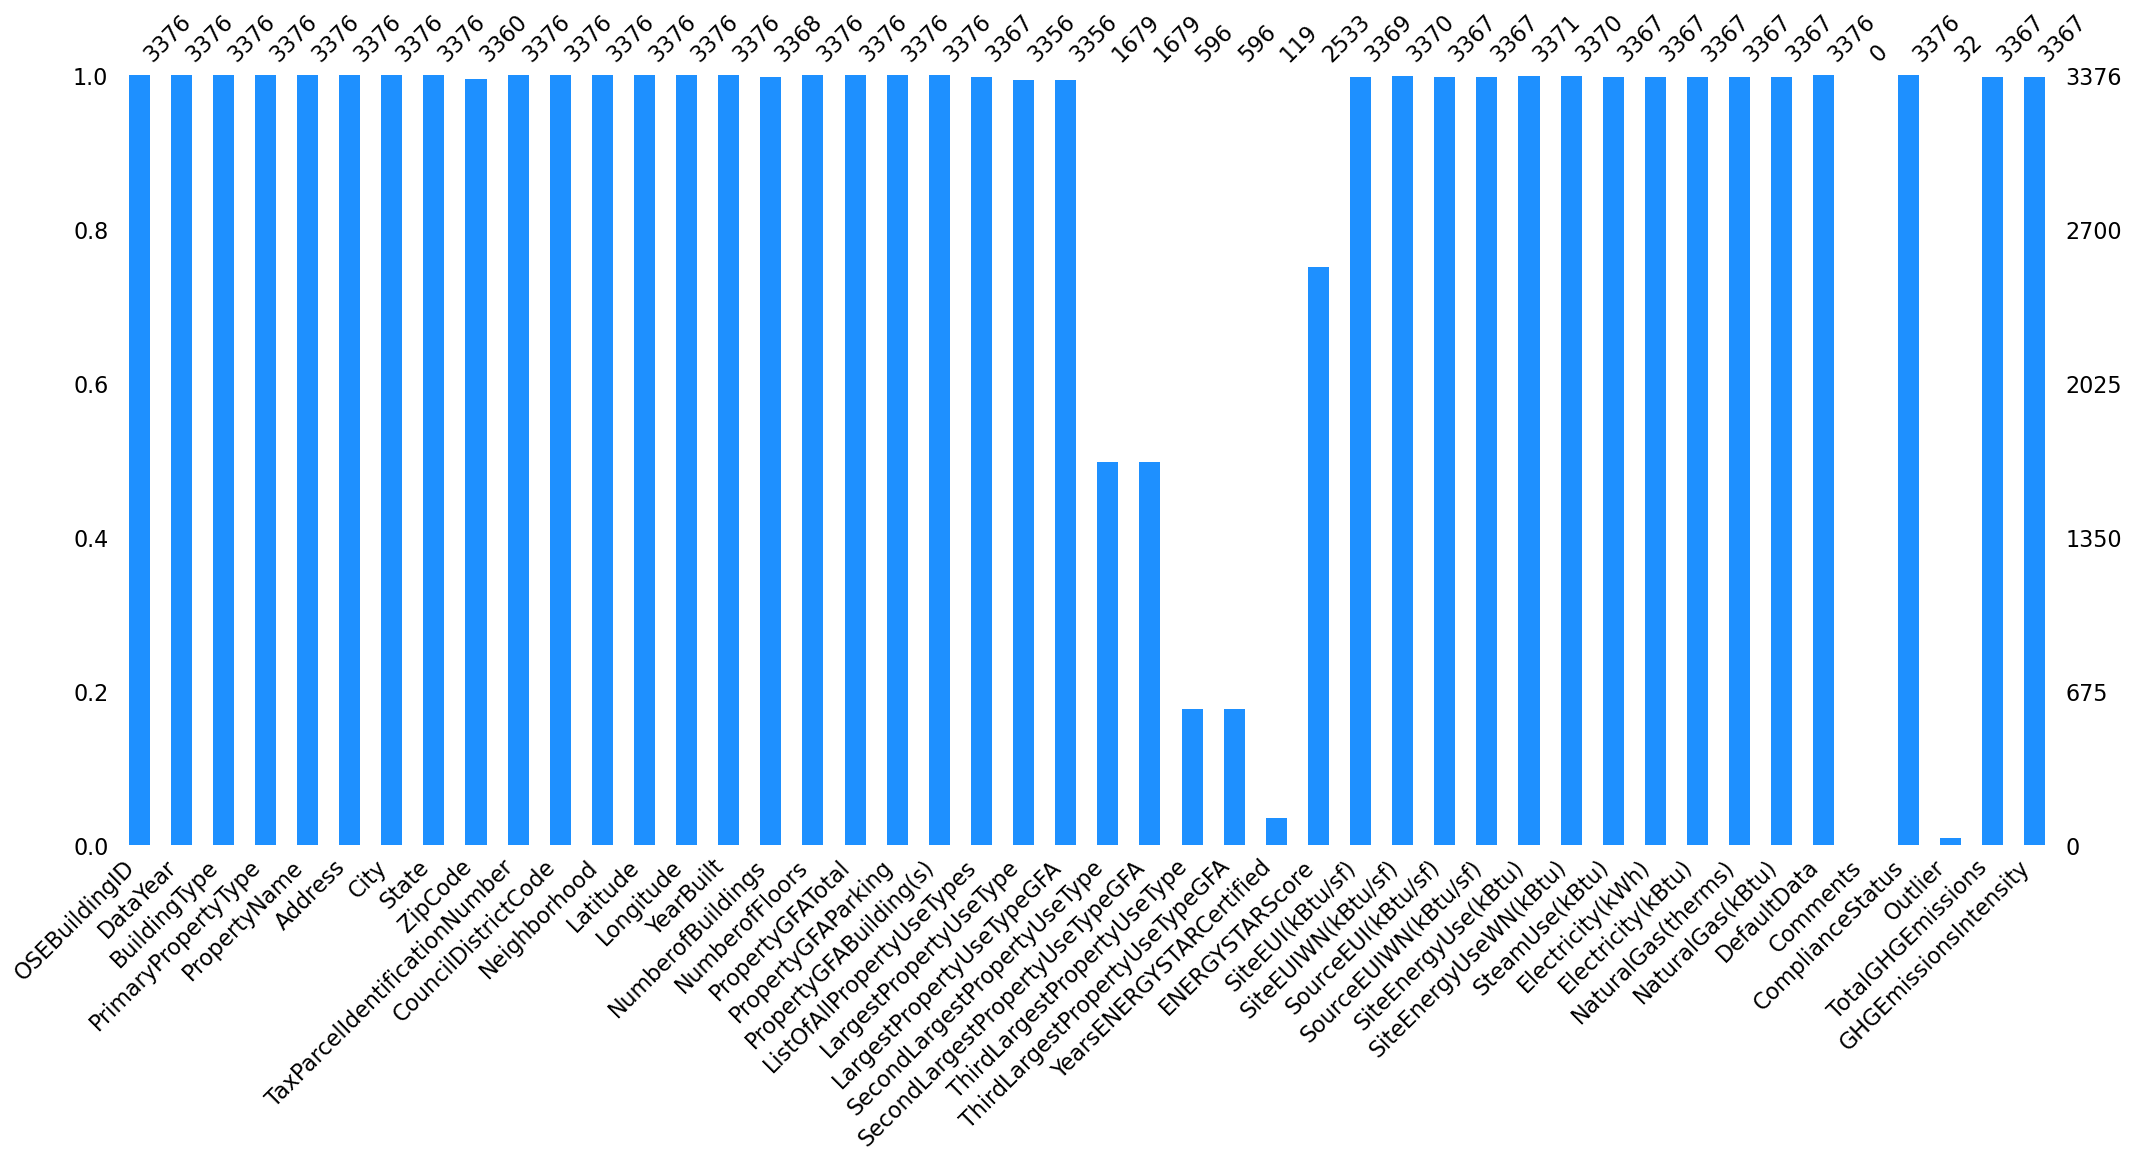

In [9]:
#Visualisation des valeurs manquantes
visuelDonneesNa(fichier)

In [10]:
# Sélection des colonnes avec un taux de remplissage < 50%
col_na = colManquantes(fichier, 50)
col_na

nombre de colonnes avec un taux de remplissage inférieur à 50% : 7


['SecondLargestPropertyUseType',
 'SecondLargestPropertyUseTypeGFA',
 'ThirdLargestPropertyUseType',
 'ThirdLargestPropertyUseTypeGFA',
 'YearsENERGYSTARCertified',
 'Comments',
 'Outlier']

In [11]:
# Suppression des colonnes avec un taux de remplissage < 50%
fichier_col_supp_50 = supprimeCol(fichier, col_na)
fichier_col_supp_50.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,ComplianceStatus,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,7456910.0,2003882.00,1.156514e+06,3946027.0,12764.52930,1276453.0,False,Compliant,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,8664479.0,0.00,9.504252e+05,3242851.0,51450.81641,5145082.0,False,Compliant,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,73937112.0,21566554.00,1.451544e+07,49526664.0,14938.00000,1493800.0,False,Compliant,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,6946800.5,2214446.25,8.115253e+05,2768924.0,18112.13086,1811213.0,False,Compliant,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,...,14656503.0,0.00,1.573449e+06,5368607.0,88039.98438,8803998.0,False,Compliant,505.01,2.88


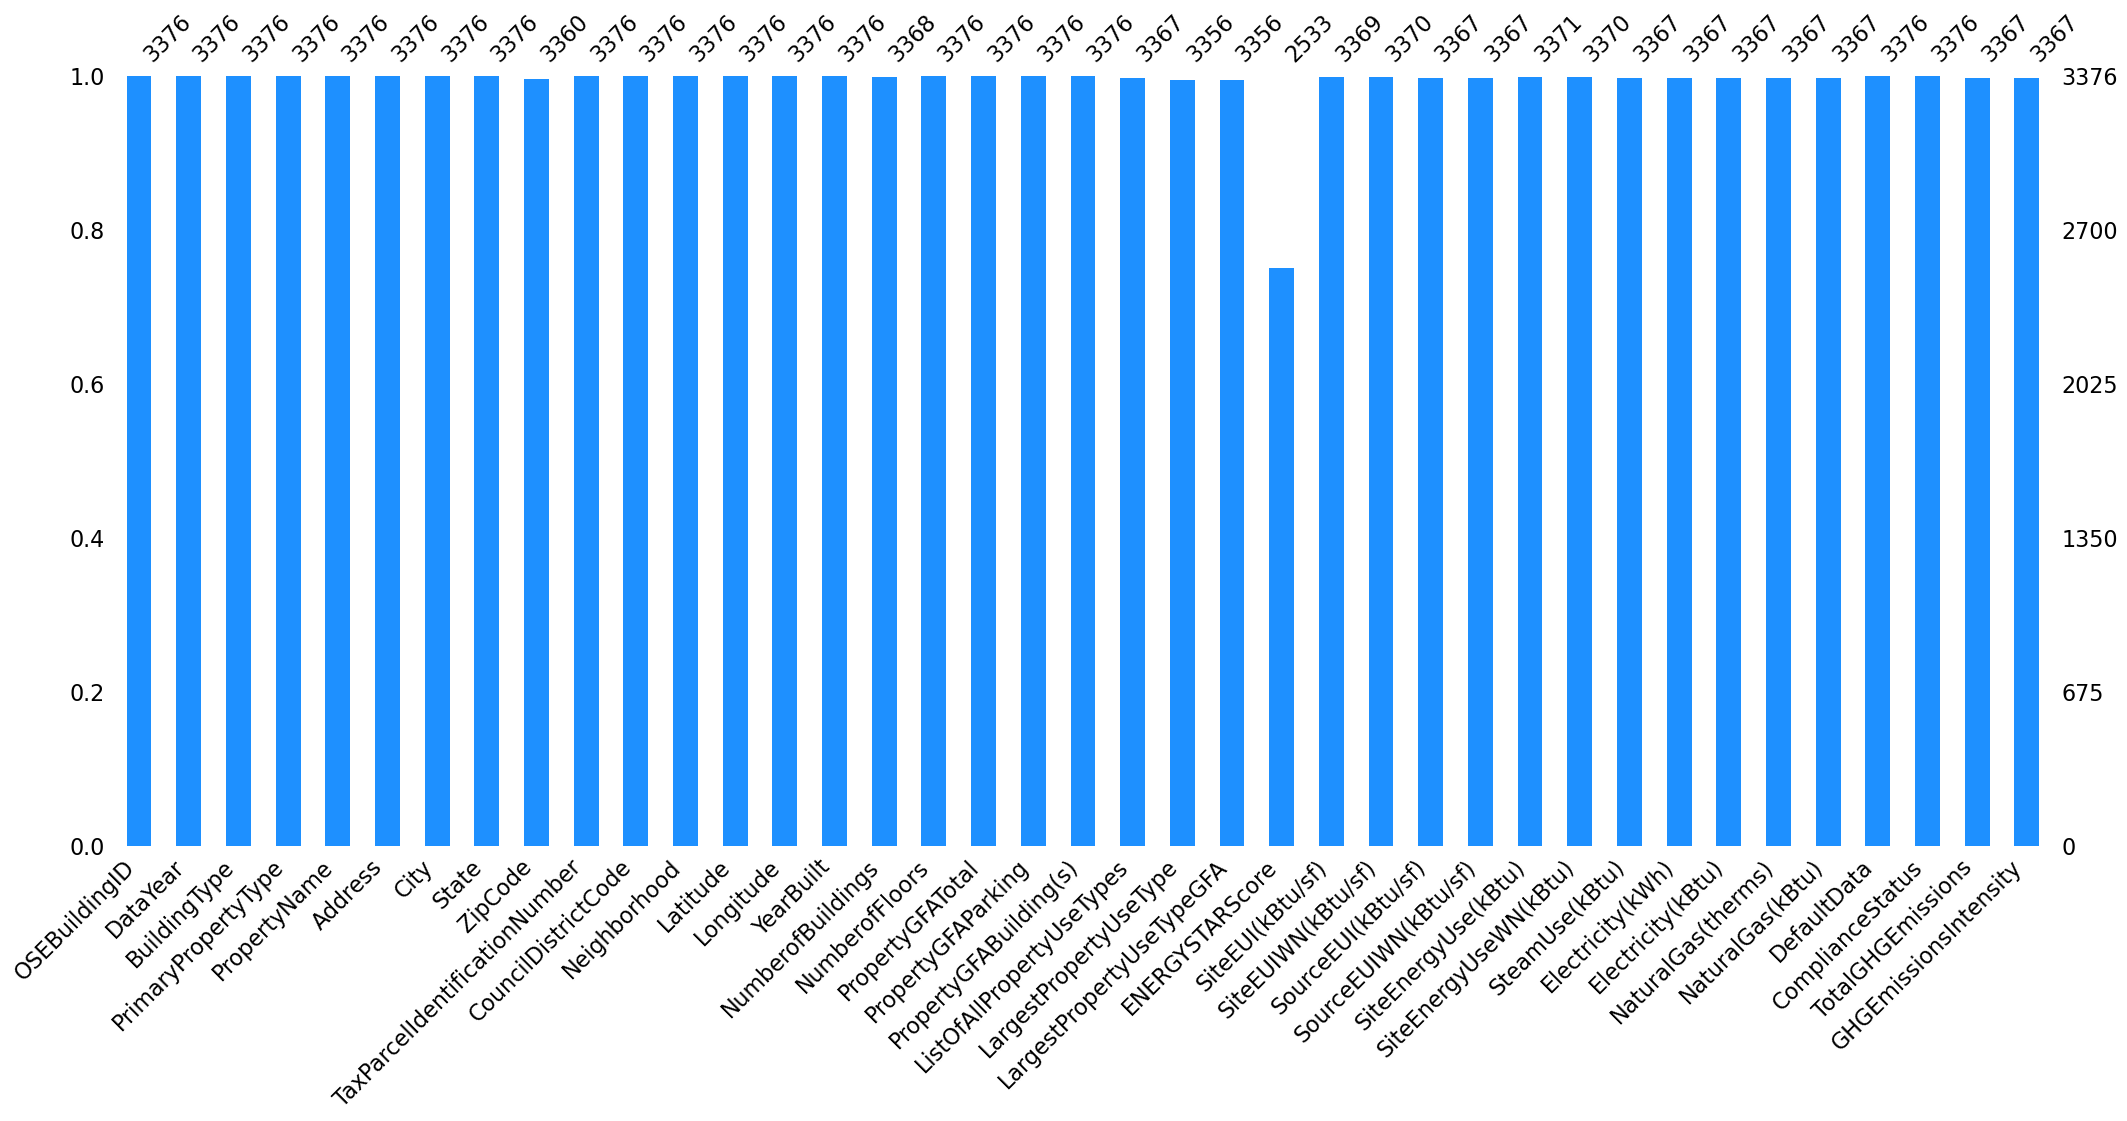

In [12]:
# visuel du taux de remplissage
visuelDonneesNa(fichier_col_supp_50)

In [13]:
# Premier choix et description des varialbes
# Liste des noms des colonnes sélectionnées
variables_list = ['OSEBuildingID', 'BuildingType', 'PrimaryPropertyType', 'YearBuilt', 'NumberofBuildings', 'NumberofFloors',
                  'PropertyGFATotal', 'PropertyGFAParking', 'PropertyGFABuilding(s)', 'SiteEUI(kBtu/sf)', 'SiteEUIWN(kBtu/sf)', 
                  'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)', 'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)', 
                  'Electricity(kWh)', 'Electricity(kBtu)', 'NaturalGas(therms)', 'NaturalGas(kBtu)', 'GHGEmissionsIntensity', 
                  'ENERGYSTARScore']

# Liste des descriptions correspondantes
descriptions = ['ID du bâtiment OSE', 'Type de bâtiment (résidentiel, commercial, etc.)', 'Type de propriété principale', 'Année de construction', 'Nombre de bâtiments', 
                'Nombre d\'étages', 'Surface totale du bâtiment et du parking', 'Surface de stationnement de la propriété', 'Surface du bâtiment de la propriété', 
                'utilisation de l\'énergie du site d\'une propriété divisée par sa superficie brute au sol', 'EUI du site normalisé (énergétique du site que la propriété aurait consommée pendant les conditions météorologiques moyennes de 30 ans)',
                'énergie de source d\'une propriété divisée par sa surface brute au sol', 'EUI de la source normalisé (kBtu/sf)', 
                'Utilisation d\'énergie du site (kBtu)', 'Utilisation d\'énergie du site normalisé (kBtu)', 'La quantité annuelle de vapeur de district consommée par la propriété sur place, mesurée en milliers d\'unités thermiques britanniques (kBtu)', 
                'La quantité annuelle d\'électricité consommée par la propriété', 'La quantité annuelle d\'électricité consommée par la propriété', 'La quantité annuelle de gaz naturel consommée par la propriété (therms)', 'La quantité annuelle de gaz naturel consommée par la propriété (kBtu)', 
                'Intensité des émissions de GES (kgCO2e/ft2)', 'Score ENERGY STAR']

# Création de la DataFrame
df_description = pd.DataFrame({
    'Nom de la colonne': variables_list,
    'Description': descriptions
})

# Ajuster les paramètres d'affichage de pandas pour afficher toutes les colonnes
pd.set_option('display.max_columns', None) 
pd.set_option('display.max_colwidth', None)

# Affichage de la DataFrame
df_description

,Nom de la colonne,Description
0,OSEBuildingID,ID du bâtiment OSE
1,BuildingType,"Type de bâtiment (résidentiel, commercial, etc.)"
2,PrimaryPropertyType,Type de propriété principale
3,YearBuilt,Année de construction
4,NumberofBuildings,Nombre de bâtiments
5,NumberofFloors,Nombre d'étages
6,PropertyGFATotal,Surface totale du bâtiment et du parking
7,PropertyGFAParking,Surface de stationnement de la propriété
8,PropertyGFABuilding(s),Surface du bâtiment de la propriété
9,SiteEUI(kBtu/sf),utilisation de l'énergie du site d'une propriété divisée par sa superficie brute au sol


In [14]:
# Sélection des varialbes
data_select = colSelection(fichier_col_supp_50, variables_list)
data_select.head()

,OSEBuildingID,BuildingType,PrimaryPropertyType,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),GHGEmissionsIntensity,ENERGYSTARScore
0,1,NonResidential,Hotel,1927,1.0,12,88434,0,88434,81.699997,84.300003,182.500000,189.000000,7226362.5,7456910.0,2003882.00,1.156514e+06,3946027.0,12764.52930,1276453.0,2.83,60.0
1,2,NonResidential,Hotel,1996,1.0,11,103566,15064,88502,94.800003,97.900002,176.100006,179.399994,8387933.0,8664479.0,0.00,9.504252e+05,3242851.0,51450.81641,5145082.0,2.86,61.0
2,3,NonResidential,Hotel,1969,1.0,41,956110,196718,759392,96.000000,97.699997,241.899994,244.100006,72587024.0,73937112.0,21566554.00,1.451544e+07,49526664.0,14938.00000,1493800.0,2.19,43.0
3,5,NonResidential,Hotel,1926,1.0,10,61320,0,61320,110.800003,113.300003,216.199997,224.000000,6794584.0,6946800.5,2214446.25,8.115253e+05,2768924.0,18112.13086,1811213.0,4.67,56.0
4,8,NonResidential,Hotel,1980,1.0,18,175580,62000,113580,114.800003,118.699997,211.399994,215.600006,14172606.0,14656503.0,0.00,1.573449e+06,5368607.0,88039.98438,8803998.0,2.88,75.0


In [15]:
# Nombre bâtiment par type
data_select["BuildingType"].value_counts()

BuildingType
NonResidential          1460
Multifamily LR (1-4)    1018
Multifamily MR (5-9)     580
Multifamily HR (10+)     110
SPS-District K-12         98
Nonresidential COS        85
Campus                    24
Nonresidential WA          1
Name: count, dtype: int64

In [16]:
# Selection des bâtiments contenant le type "NonResidential"
data_select_filtre = data_select[data_select["BuildingType"].str.contains("(?i)NonResidential", na=False)]
data_select_filtre.head()

,OSEBuildingID,BuildingType,PrimaryPropertyType,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),GHGEmissionsIntensity,ENERGYSTARScore
0,1,NonResidential,Hotel,1927,1.0,12,88434,0,88434,81.699997,84.300003,182.500000,189.000000,7226362.5,7456910.0,2003882.00,1.156514e+06,3946027.0,12764.52930,1276453.0,2.83,60.0
1,2,NonResidential,Hotel,1996,1.0,11,103566,15064,88502,94.800003,97.900002,176.100006,179.399994,8387933.0,8664479.0,0.00,9.504252e+05,3242851.0,51450.81641,5145082.0,2.86,61.0
2,3,NonResidential,Hotel,1969,1.0,41,956110,196718,759392,96.000000,97.699997,241.899994,244.100006,72587024.0,73937112.0,21566554.00,1.451544e+07,49526664.0,14938.00000,1493800.0,2.19,43.0
3,5,NonResidential,Hotel,1926,1.0,10,61320,0,61320,110.800003,113.300003,216.199997,224.000000,6794584.0,6946800.5,2214446.25,8.115253e+05,2768924.0,18112.13086,1811213.0,4.67,56.0
4,8,NonResidential,Hotel,1980,1.0,18,175580,62000,113580,114.800003,118.699997,211.399994,215.600006,14172606.0,14656503.0,0.00,1.573449e+06,5368607.0,88039.98438,8803998.0,2.88,75.0


In [17]:
# Nombre bâtiment par type (vérification)
data_select_filtre["BuildingType"].value_counts()

BuildingType
NonResidential        1460
Nonresidential COS      85
Nonresidential WA        1
Name: count, dtype: int64

In [18]:
# Conversion de l'id des batiments et de l'année de conctruction en facteur
data_select_filtre[["OSEBuildingID", "YearBuilt"]] = data_select_filtre[["OSEBuildingID", "YearBuilt"]].astype('category')


/var/folders/h0/8500ftrn70xcn1_yvyhmwns00000gn/T/ipykernel_7826/1255165448.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_select_filtre[["OSEBuildingID", "YearBuilt"]] = data_select_filtre[["OSEBuildingID", "YearBuilt"]].astype('category')


In [19]:
# Information sur les données
data_select_filtre.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1546 entries, 0 to 3375
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   OSEBuildingID           1546 non-null   category
 1   BuildingType            1546 non-null   object  
 2   PrimaryPropertyType     1546 non-null   object  
 3   YearBuilt               1546 non-null   category
 4   NumberofBuildings       1544 non-null   float64 
 5   NumberofFloors          1546 non-null   int64   
 6   PropertyGFATotal        1546 non-null   int64   
 7   PropertyGFAParking      1546 non-null   int64   
 8   PropertyGFABuilding(s)  1546 non-null   int64   
 9   SiteEUI(kBtu/sf)        1543 non-null   float64 
 10  SiteEUIWN(kBtu/sf)      1543 non-null   float64 
 11  SourceEUI(kBtu/sf)      1544 non-null   float64 
 12  SourceEUIWN(kBtu/sf)    1544 non-null   float64 
 13  SiteEnergyUse(kBtu)     1544 non-null   float64 
 14  SiteEnergyUseWN(kBtu)   1543 

In [20]:
# Catégorisation des variables
quali,quanti = categoriseVariables(data_select_filtre)

In [21]:
# variables qualitatives
quali

['OSEBuildingID', 'BuildingType', 'PrimaryPropertyType', 'YearBuilt']

In [22]:
# variables quantitatives
quanti

['NumberofBuildings',
 'NumberofFloors',
 'PropertyGFATotal',
 'PropertyGFAParking',
 'PropertyGFABuilding(s)',
 'SiteEUI(kBtu/sf)',
 'SiteEUIWN(kBtu/sf)',
 'SourceEUI(kBtu/sf)',
 'SourceEUIWN(kBtu/sf)',
 'SiteEnergyUse(kBtu)',
 'SiteEnergyUseWN(kBtu)',
 'SteamUse(kBtu)',
 'Electricity(kWh)',
 'Electricity(kBtu)',
 'NaturalGas(therms)',
 'NaturalGas(kBtu)',
 'GHGEmissionsIntensity',
 'ENERGYSTARScore']

In [23]:
#histoBoxPlotQuanti(fichier_col_supp_50, quanti)

In [24]:
# verification des doublons
data_select_filtre["OSEBuildingID"].duplicated().sum()

0

In [25]:
data_select_filtre.describe()

,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),GHGEmissionsIntensity,ENERGYSTARScore
count,1544.000000,1546.000000,1.546000e+03,1546.000000,1.546000e+03,1543.000000,1543.000000,1544.000000,1544.000000,1.544000e+03,1.543000e+03,1.544000e+03,1.544000e+03,1.544000e+03,1.544000e+03,1.544000e+03,1544.000000,1006.000000
mean,1.036269,4.283959,1.118044e+05,13822.981889,9.798146e+04,74.203953,76.585677,181.615026,183.843588,7.642371e+06,7.749996e+06,4.951487e+05,1.590416e+06,5.426501e+06,1.670065e+04,1.670065e+06,1.607506,63.830020
std,0.569231,6.783014,1.915023e+05,43679.918511,1.682204e+05,75.588468,76.576520,190.144184,190.131202,1.865844e+07,1.882062e+07,5.306124e+06,3.821341e+06,1.303841e+07,5.504752e+04,5.504752e+06,2.245002,28.915866
min,0.000000,0.000000,1.128500e+04,0.000000,3.636000e+03,0.000000,0.000000,0.000000,-2.100000,0.000000e+00,0.000000e+00,0.000000e+00,-3.382680e+04,-1.154170e+05,0.000000e+00,0.000000e+00,-0.020000,1.000000
25%,1.000000,1.000000,2.877000e+04,0.000000,2.770000e+04,34.250000,36.099998,78.699997,81.000000,1.204670e+06,1.265929e+06,0.000000e+00,2.077251e+05,7.087580e+05,0.000000e+00,0.000000e+00,0.340000,44.000000
50%,1.000000,2.000000,4.730250e+04,0.000000,4.511350e+04,53.200001,55.799999,137.750000,140.099998,2.609590e+06,2.739359e+06,0.000000e+00,4.788943e+05,1.633988e+06,4.322415e+03,4.322415e+05,0.850000,71.000000
75%,1.000000,4.000000,1.029090e+05,0.000000,9.261400e+04,83.750000,87.400002,210.375004,210.624996,6.968646e+06,7.192840e+06,0.000000e+00,1.469022e+06,5.012304e+06,1.411576e+04,1.411576e+06,1.932500,89.000000
max,9.000000,99.000000,1.952220e+06,512608.000000,1.765970e+06,834.400024,834.400024,2620.000000,2620.000000,2.930908e+08,2.966717e+08,1.349435e+08,8.046087e+07,2.745325e+08,1.381912e+06,1.381912e+08,25.710000,100.000000


In [26]:
# Filtre des valeurs inférieures à 0
## selectionner les colonnes quantitatives
data_quanti = data_select_filtre[quanti]
## Filtrer les lignes où les valeurs des colonnes quantitatives sont inférieures à 0
negative_quanti_val = data_quanti[(data_quanti < 0).any(axis = 1)]
negative_quanti_val

,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),GHGEmissionsIntensity,ENERGYSTARScore
3206,1.0,6,52000,0,52000,7.1,5.0,2.0,-2.1,342726.0938,240132.0938,0.0,-33826.80078,-115417.0,0.0,0.0,-0.02,100.0


In [27]:
# Suppression des valeurs inférieures à 0
data_select_filtre = data_select_filtre.drop(negative_quanti_val.index).reset_index(drop=True)
data_select_filtre.head()

,OSEBuildingID,BuildingType,PrimaryPropertyType,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),GHGEmissionsIntensity,ENERGYSTARScore
0,1,NonResidential,Hotel,1927,1.0,12,88434,0,88434,81.699997,84.300003,182.500000,189.000000,7226362.5,7456910.0,2003882.00,1.156514e+06,3946027.0,12764.52930,1276453.0,2.83,60.0
1,2,NonResidential,Hotel,1996,1.0,11,103566,15064,88502,94.800003,97.900002,176.100006,179.399994,8387933.0,8664479.0,0.00,9.504252e+05,3242851.0,51450.81641,5145082.0,2.86,61.0
2,3,NonResidential,Hotel,1969,1.0,41,956110,196718,759392,96.000000,97.699997,241.899994,244.100006,72587024.0,73937112.0,21566554.00,1.451544e+07,49526664.0,14938.00000,1493800.0,2.19,43.0
3,5,NonResidential,Hotel,1926,1.0,10,61320,0,61320,110.800003,113.300003,216.199997,224.000000,6794584.0,6946800.5,2214446.25,8.115253e+05,2768924.0,18112.13086,1811213.0,4.67,56.0
4,8,NonResidential,Hotel,1980,1.0,18,175580,62000,113580,114.800003,118.699997,211.399994,215.600006,14172606.0,14656503.0,0.00,1.573449e+06,5368607.0,88039.98438,8803998.0,2.88,75.0


In [28]:
# Choix des variables finales
quali = ['OSEBuildingID', 'YearBuilt']
quanti = ['NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking', 'PropertyGFABuilding(s)', 'SiteEUI(kBtu/sf)', 'SiteEUIWN(kBtu/sf)',
         'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)', 'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)', 'Electricity(kBtu)', 'NaturalGas(kBtu)', 'GHGEmissionsIntensity', 'ENERGYSTARScore']

# Dataframe finale
data_final = data_select_filtre[quali + quanti]
data_final.head()

,OSEBuildingID,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),GHGEmissionsIntensity,ENERGYSTARScore
0,1,1927,1.0,12,88434,0,88434,81.699997,84.300003,182.500000,189.000000,7226362.5,7456910.0,2003882.00,3946027.0,1276453.0,2.83,60.0
1,2,1996,1.0,11,103566,15064,88502,94.800003,97.900002,176.100006,179.399994,8387933.0,8664479.0,0.00,3242851.0,5145082.0,2.86,61.0
2,3,1969,1.0,41,956110,196718,759392,96.000000,97.699997,241.899994,244.100006,72587024.0,73937112.0,21566554.00,49526664.0,1493800.0,2.19,43.0
3,5,1926,1.0,10,61320,0,61320,110.800003,113.300003,216.199997,224.000000,6794584.0,6946800.5,2214446.25,2768924.0,1811213.0,4.67,56.0
4,8,1980,1.0,18,175580,62000,113580,114.800003,118.699997,211.399994,215.600006,14172606.0,14656503.0,0.00,5368607.0,8803998.0,2.88,75.0


In [29]:
# Description de la dataframe finale
descriptionData(data_final)

La dataframe contient 1545 lignes et 18 colonnes.


In [30]:
# Description des variables finales
data_final_describe = df_description[df_description['Nom de la colonne'].isin(data_final.columns)].reset_index(drop=True)
data_final_describe

,Nom de la colonne,Description
0,OSEBuildingID,ID du bâtiment OSE
1,YearBuilt,Année de construction
2,NumberofBuildings,Nombre de bâtiments
3,NumberofFloors,Nombre d'étages
4,PropertyGFATotal,Surface totale du bâtiment et du parking
5,PropertyGFAParking,Surface de stationnement de la propriété
6,PropertyGFABuilding(s),Surface du bâtiment de la propriété
7,SiteEUI(kBtu/sf),utilisation de l'énergie du site d'une propriété divisée par sa superficie brute au sol
8,SiteEUIWN(kBtu/sf),EUI du site normalisé (énergétique du site que la propriété aurait consommée pendant les conditions météorologiques moyennes de 30 ans)
9,SourceEUI(kBtu/sf),énergie de source d'une propriété divisée par sa surface brute au sol


In [31]:
# Vérification des valeurs manquantes
data_final.isnull().sum()

OSEBuildingID               0
YearBuilt                   0
NumberofBuildings           2
NumberofFloors              0
PropertyGFATotal            0
PropertyGFAParking          0
PropertyGFABuilding(s)      0
SiteEUI(kBtu/sf)            3
SiteEUIWN(kBtu/sf)          3
SourceEUI(kBtu/sf)          2
SourceEUIWN(kBtu/sf)        2
SiteEnergyUse(kBtu)         2
SiteEnergyUseWN(kBtu)       3
SteamUse(kBtu)              2
Electricity(kBtu)           2
NaturalGas(kBtu)            2
GHGEmissionsIntensity       2
ENERGYSTARScore           540
dtype: int64

In [32]:
# Remplacement des valeurs manquantes par la methode statistique appropriée
## selection des colonnes quantitatives avec des valeurs manquantes a remplacer
quanti_select = ['NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking', 'PropertyGFABuilding(s)', 'SiteEUI(kBtu/sf)', 'SiteEUIWN(kBtu/sf)',
         'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)', 'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)', 'Electricity(kBtu)', 'NaturalGas(kBtu)', 'GHGEmissionsIntensity']
data_final = remplacerValParStats(data_final, quanti_select)

Coefficient d'asymétrie de skewness pour NumberofBuildings: 7.99549171350431 , Méthode de remplacement utilisée : médiane
Coefficient d'asymétrie de skewness pour NumberofFloors: 5.833270323672367 , Méthode de remplacement utilisée : médiane
Coefficient d'asymétrie de skewness pour PropertyGFATotal: 4.729565425456481 , Méthode de remplacement utilisée : médiane
Coefficient d'asymétrie de skewness pour PropertyGFAParking: 5.033754800476555 , Méthode de remplacement utilisée : médiane
Coefficient d'asymétrie de skewness pour PropertyGFABuilding(s): 5.003158643035811 , Méthode de remplacement utilisée : médiane
Coefficient d'asymétrie de skewness pour SiteEUI(kBtu/sf): 3.6828967727814805 , Méthode de remplacement utilisée : médiane
Coefficient d'asymétrie de skewness pour SiteEUIWN(kBtu/sf): 3.587332760117949 , Méthode de remplacement utilisée : médiane
Coefficient d'asymétrie de skewness pour SourceEUI(kBtu/sf): 4.8827159244462885 , Méthode de remplacement utilisée : médiane
Coefficient 

In [33]:
# Revérification des valeurs manquantes
data_final.isnull().sum()

OSEBuildingID               0
YearBuilt                   0
NumberofBuildings           0
NumberofFloors              0
PropertyGFATotal            0
PropertyGFAParking          0
PropertyGFABuilding(s)      0
SiteEUI(kBtu/sf)            0
SiteEUIWN(kBtu/sf)          0
SourceEUI(kBtu/sf)          0
SourceEUIWN(kBtu/sf)        0
SiteEnergyUse(kBtu)         0
SiteEnergyUseWN(kBtu)       0
SteamUse(kBtu)              0
Electricity(kBtu)           0
NaturalGas(kBtu)            0
GHGEmissionsIntensity       0
ENERGYSTARScore           540
dtype: int64

In [34]:
data_final.head()

,OSEBuildingID,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),GHGEmissionsIntensity,ENERGYSTARScore
0,1,1927,1.0,12,88434,0,88434,81.699997,84.300003,182.500000,189.000000,7226362.5,7456910.0,2003882.00,3946027.0,1276453.0,2.83,60.0
1,2,1996,1.0,11,103566,15064,88502,94.800003,97.900002,176.100006,179.399994,8387933.0,8664479.0,0.00,3242851.0,5145082.0,2.86,61.0
2,3,1969,1.0,41,956110,196718,759392,96.000000,97.699997,241.899994,244.100006,72587024.0,73937112.0,21566554.00,49526664.0,1493800.0,2.19,43.0
3,5,1926,1.0,10,61320,0,61320,110.800003,113.300003,216.199997,224.000000,6794584.0,6946800.5,2214446.25,2768924.0,1811213.0,4.67,56.0
4,8,1980,1.0,18,175580,62000,113580,114.800003,118.699997,211.399994,215.600006,14172606.0,14656503.0,0.00,5368607.0,8803998.0,2.88,75.0


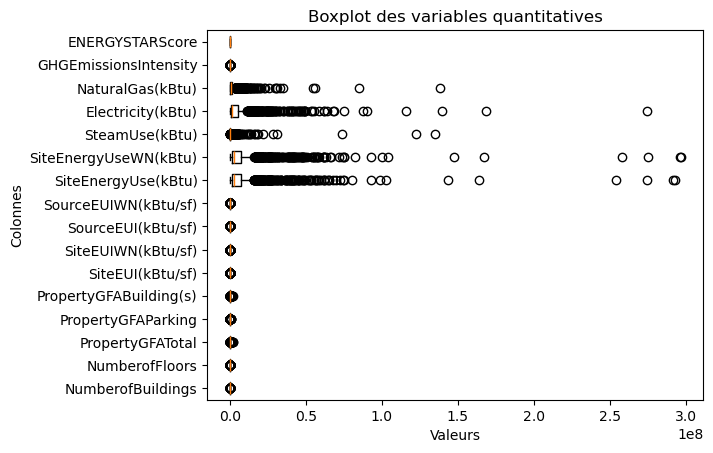

In [35]:
# fonction qui retourne un boxplot des valeurs aberrantes des variables quantitatives  
def boxplotQuanti(data, colonnes):
    plt.boxplot([data[col].dropna() for col in colonnes ], labels= colonnes, vert= False)
    plt.title("Boxplot des variables quantitatives")
    plt.xlabel("Valeurs")
    plt.ylabel("Colonnes")
    plt.show()

# visualisation des valeurs aberrantes
boxplotQuanti(data_final, quanti)

In [36]:
# Description des variables quantitatives
data_final.describe()

,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),GHGEmissionsIntensity,ENERGYSTARScore
count,1545.000000,1545.000000,1.545000e+03,1545.000000,1.545000e+03,1545.000000,1545.000000,1545.000000,1545.000000,1.545000e+03,1.545000e+03,1.545000e+03,1.545000e+03,1.545000e+03,1545.000000,1005.000000
mean,1.036246,4.282848,1.118432e+05,13831.928803,9.801122e+04,74.206602,76.591651,181.674693,183.907443,7.640588e+06,7.745129e+06,4.948282e+05,5.425179e+06,1.669544e+06,1.607579,63.794030
std,0.569047,6.785070,1.915582e+05,43692.644201,1.682708e+05,75.525864,76.510706,190.034133,190.017186,1.865235e+07,1.880875e+07,5.304420e+06,1.303414e+07,5.502985e+06,2.244058,28.907711
min,0.000000,0.000000,1.128500e+04,0.000000,3.636000e+03,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,1.000000
25%,1.000000,1.000000,2.876000e+04,0.000000,2.769000e+04,34.299999,36.200001,79.300003,81.300003,1.207504e+06,1.267463e+06,0.000000e+00,7.102750e+05,0.000000e+00,0.340000,44.000000
50%,1.000000,2.000000,4.723700e+04,0.000000,4.508200e+04,53.200001,55.799999,137.899994,140.199997,2.615248e+06,2.739967e+06,0.000000e+00,1.634669e+06,4.330910e+05,0.850000,71.000000
75%,1.000000,4.000000,1.029300e+05,0.000000,9.279200e+04,83.699997,87.400002,210.300003,210.399994,6.963616e+06,7.181600e+06,0.000000e+00,5.009101e+06,1.410803e+06,1.930000,89.000000
max,9.000000,99.000000,1.952220e+06,512608.000000,1.765970e+06,834.400024,834.400024,2620.000000,2620.000000,2.930908e+08,2.966717e+08,1.349435e+08,2.745325e+08,1.381912e+08,25.710000,100.000000


In [37]:
# Remplacement des valeurs trop grandes (supérieures à 3 fois l'écart-type) par la médiane
data_final = remplacerValeursMaxParMediane(data_final, quanti_select)

In [38]:
# Visuel sur les valeurs
data_final.head()

,OSEBuildingID,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),GHGEmissionsIntensity,ENERGYSTARScore
0,1,1927,1.0,12,88434,0,88434,81.699997,84.300003,182.500000,189.000000,7226362.50,7456910.00,2003882.00,3946027.0,1276453.0,2.83,60.0
1,2,1996,1.0,11,103566,15064,88502,94.800003,97.900002,176.100006,179.399994,8387933.00,8664479.00,0.00,3242851.0,5145082.0,2.86,61.0
2,3,1969,1.0,2,47237,0,45082,96.000000,97.699997,241.899994,244.100006,2615247.75,2739966.75,0.00,1634669.0,1493800.0,2.19,43.0
3,5,1926,1.0,10,61320,0,61320,110.800003,113.300003,216.199997,224.000000,6794584.00,6946800.50,2214446.25,2768924.0,1811213.0,4.67,56.0
4,8,1980,1.0,18,175580,62000,113580,114.800003,118.699997,211.399994,215.600006,14172606.00,14656503.00,0.00,5368607.0,8803998.0,2.88,75.0


In [39]:
# Description des variables quantitatives
data_final.describe()

,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),GHGEmissionsIntensity,ENERGYSTARScore
count,1545.000000,1545.000000,1545.000000,1545.000000,1545.000000,1545.000000,1545.000000,1545.000000,1545.000000,1.545000e+03,1.545000e+03,1.545000e+03,1.545000e+03,1.545000e+03,1545.000000,1005.000000
mean,0.975405,3.455016,86821.899676,7502.137864,76570.703560,67.128997,69.281683,166.996505,168.845243,6.150506e+06,6.319069e+06,2.045137e+05,4.147233e+06,1.270837e+06,1.357107,63.794030
std,0.205282,3.472983,101970.518499,21750.567712,87768.246638,53.705992,54.390423,133.127162,132.488583,9.415650e+06,9.633227e+06,1.186837e+06,6.493778e+06,2.314277e+06,1.491695,28.907711
min,0.000000,0.000000,11285.000000,0.000000,3636.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,1.000000
25%,1.000000,1.000000,28760.000000,0.000000,27690.000000,34.299999,36.200001,79.300003,81.300003,1.207504e+06,1.267463e+06,0.000000e+00,7.102750e+05,0.000000e+00,0.340000,44.000000
50%,1.000000,2.000000,47237.000000,0.000000,45082.000000,53.200001,55.799999,137.899994,140.199997,2.615248e+06,2.739967e+06,0.000000e+00,1.634669e+06,4.330910e+05,0.850000,71.000000
75%,1.000000,4.000000,95117.000000,0.000000,86204.000000,80.300003,83.500000,202.899994,204.699997,6.674180e+06,6.849826e+06,0.000000e+00,4.593859e+06,1.331883e+06,1.800000,89.000000
max,2.000000,24.000000,635824.000000,141600.000000,597519.000000,298.299988,303.799988,747.700012,745.400024,6.219718e+07,6.317282e+07,1.628457e+07,4.452184e+07,1.813892e+07,8.210000,100.000000


In [40]:
# Nombre de valeurs À 0 présentes par colonne
data_final[data_final == 0].count() 

OSEBuildingID                0
YearBuilt                    0
NumberofBuildings           52
NumberofFloors              14
PropertyGFATotal             0
PropertyGFAParking        1259
PropertyGFABuilding(s)       0
SiteEUI(kBtu/sf)             1
SiteEUIWN(kBtu/sf)          10
SourceEUI(kBtu/sf)           4
SourceEUIWN(kBtu/sf)        13
SiteEnergyUse(kBtu)          2
SiteEnergyUseWN(kBtu)       10
SteamUse(kBtu)            1442
Electricity(kBtu)            4
NaturalGas(kBtu)           459
GHGEmissionsIntensity        5
ENERGYSTARScore              0
dtype: int64

In [41]:
# Revérification du nombre de valeurs À 0 présentes par colonne
data_final[data_final == 0].count() 

OSEBuildingID                0
YearBuilt                    0
NumberofBuildings           52
NumberofFloors              14
PropertyGFATotal             0
PropertyGFAParking        1259
PropertyGFABuilding(s)       0
SiteEUI(kBtu/sf)             1
SiteEUIWN(kBtu/sf)          10
SourceEUI(kBtu/sf)           4
SourceEUIWN(kBtu/sf)        13
SiteEnergyUse(kBtu)          2
SiteEnergyUseWN(kBtu)       10
SteamUse(kBtu)            1442
Electricity(kBtu)            4
NaturalGas(kBtu)           459
GHGEmissionsIntensity        5
ENERGYSTARScore              0
dtype: int64

In [42]:
# Description de la dataframe
descriptionData(data_final)

La dataframe contient 1545 lignes et 18 colonnes.


In [43]:
data_final[data_final["PropertyGFAParking"] == 0]

,OSEBuildingID,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),GHGEmissionsIntensity,ENERGYSTARScore
0,1,1927,1.0,12,88434,0,88434,81.699997,84.300003,182.500000,189.000000,7.226362e+06,7.456910e+06,2003882.00,3.946027e+06,1.276453e+06,2.83,60.0
2,3,1969,1.0,2,47237,0,45082,96.000000,97.699997,241.899994,244.100006,2.615248e+06,2.739967e+06,0.00,1.634669e+06,1.493800e+06,2.19,43.0
3,5,1926,1.0,10,61320,0,61320,110.800003,113.300003,216.199997,224.000000,6.794584e+06,6.946800e+06,2214446.25,2.768924e+06,1.811213e+06,4.67,56.0
6,10,1926,1.0,11,83008,0,83008,70.800003,74.500000,146.600006,154.699997,5.758795e+06,6.062768e+06,0.00,2.811215e+06,2.947580e+06,2.12,27.0
7,11,1926,1.0,8,102761,0,102761,61.299999,68.800003,141.699997,152.300003,6.298132e+06,7.067882e+06,2276286.50,3.636655e+06,3.851890e+05,2.16,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1540,50222,1990,1.0,1,12294,0,12294,69.099998,76.699997,161.699997,176.100006,8.497457e+05,9.430032e+05,0.00,5.242709e+05,3.254750e+05,1.70,46.0
1541,50223,2004,1.0,1,16000,0,16000,59.400002,65.900002,114.199997,118.900002,9.502762e+05,1.053706e+06,0.00,3.965461e+05,5.537300e+05,2.01,NaN
1542,50224,1974,1.0,1,13157,0,13157,53.200001,55.799999,744.799988,140.199997,5.765898e+06,6.053764e+06,0.00,1.792159e+06,3.973739e+06,0.85,NaN
1543,50225,1989,1.0,1,14101,0,14101,51.000000,55.500000,105.300003,110.800003,7.194712e+05,7.828413e+05,0.00,3.488702e+05,3.706010e+05,1.57,NaN


In [44]:
# Remplacement des valeurs nulles par KNN
data_final = remplacerZeroParKNN(data_final, quanti_select)
data_final.head()

,OSEBuildingID,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),GHGEmissionsIntensity,ENERGYSTARScore
0,1,1927,1.0,12.0,88434.0,42554.6,88434.0,81.699997,84.300003,182.500000,189.000000,7226362.50,7456910.00,2.003882e+06,3946027.0,1276453.0,2.83,60.0
1,2,1996,1.0,11.0,103566.0,15064.0,88502.0,94.800003,97.900002,176.100006,179.399994,8387933.00,8664479.00,2.509867e+06,3242851.0,5145082.0,2.86,61.0
2,3,1969,1.0,2.0,47237.0,14684.0,45082.0,96.000000,97.699997,241.899994,244.100006,2615247.75,2739966.75,9.012231e+05,1634669.0,1493800.0,2.19,43.0
3,5,1926,1.0,10.0,61320.0,33460.0,61320.0,110.800003,113.300003,216.199997,224.000000,6794584.00,6946800.50,2.214446e+06,2768924.0,1811213.0,4.67,56.0
4,8,1980,1.0,18.0,175580.0,62000.0,113580.0,114.800003,118.699997,211.399994,215.600006,14172606.00,14656503.00,4.293092e+06,5368607.0,8803998.0,2.88,75.0


In [45]:
# dernière vérification Nombre de valeurs À 0 présentes par colonne
data_final[data_final == 0].count() 

OSEBuildingID             0
YearBuilt                 0
NumberofBuildings         0
NumberofFloors            0
PropertyGFATotal          0
PropertyGFAParking        0
PropertyGFABuilding(s)    0
SiteEUI(kBtu/sf)          0
SiteEUIWN(kBtu/sf)        0
SourceEUI(kBtu/sf)        0
SourceEUIWN(kBtu/sf)      0
SiteEnergyUse(kBtu)       0
SiteEnergyUseWN(kBtu)     0
SteamUse(kBtu)            0
Electricity(kBtu)         0
NaturalGas(kBtu)          0
GHGEmissionsIntensity     0
ENERGYSTARScore           0
dtype: int64

Les valeurs à 0 des colonnes PropertyGFAParking (Surface de stationnement de la propriété) et SteamUse (La quantité annuelle de vapeur de district consommée par la propriété) n'ont pas changés, celà semble bizare mais pas impossible donc on va les laisser telquel .

In [46]:
# Détection des valeurs abérrantes
## Methode de l'intervalle interquartile des variables quantitatives
def detectOutlierIqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    born_inf = Q1 - 1.5 * IQR
    born_sup = Q3 + 1.5 * IQR
    outliers = data[(data[column] < born_inf) | (data[column] > born_sup)]
    return outliers

outliers = detectOutlierIqr(data_final, "SiteEnergyUse(kBtu)")#"SiteEnergyUseWN(kBtu)")
outliers

,OSEBuildingID,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),GHGEmissionsIntensity,ENERGYSTARScore
9,15,1969,1.0,11.0,153163.0,19279.0,133884.0,119.599998,124.300003,228.199997,233.000000,16016644.0,16646930.0,5.237166e+06,6187627.0,4591850.0,4.51,30.0
10,16,1998,1.0,2.0,333176.0,61161.0,272015.0,80.000000,80.400002,199.000000,199.399994,26941110.0,27070114.0,5.999360e+06,18083049.0,2858700.0,2.22,36.0
12,18,1980,1.0,2.0,315952.0,57600.0,258352.0,75.500000,76.199997,179.899994,180.699997,22325364.0,22524948.0,4.337738e+06,13904183.0,4083440.0,2.05,58.0
14,21,2004,1.0,11.0,412000.0,57000.0,355000.0,50.799999,51.099998,155.600006,156.000000,18588860.0,18706912.0,7.375595e+05,17851297.0,571410.4,0.44,NaN
16,23,1983,1.0,2.0,416281.0,85000.0,331281.0,96.300003,98.599998,228.500000,232.800003,33556756.0,34351920.0,1.382177e+07,21225277.0,12331475.0,1.93,31.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1507,49972,1998,1.0,6.0,203030.0,94587.6,203030.0,252.000000,243.840002,561.000000,539.460010,51168308.0,52406760.0,9.193485e+06,28614613.0,7616819.2,0.98,NaN
1508,49979,1953,1.0,3.4,166991.0,17350.4,166991.0,95.599998,99.400002,211.800003,215.699997,15965859.0,16591973.0,4.955044e+06,8902529.0,7063329.0,2.62,19.0
1511,49985,2014,1.0,6.0,427181.0,72729.2,427181.0,38.299999,39.400002,109.800003,111.900002,16371039.0,16810854.0,3.386825e+06,14213039.0,2157998.0,0.50,99.0
1515,50031,2015,1.0,10.0,513816.0,71238.0,513816.0,52.099998,52.099998,153.100006,153.100006,18760766.0,18760766.0,9.473079e+05,16953109.0,1807655.0,0.42,NaN


In [47]:
# Description des valeurs abérrantes
descriptionData(outliers)

La dataframe contient 164 lignes et 18 colonnes.


In [48]:
# Suppression des valeurs aberrantes avec IQR
def remove_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]

# Exemple d'application
data_clean = remove_outliers(data_final, "SiteEnergyUse(kBtu)")

In [49]:
data_clean.head()

,OSEBuildingID,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),GHGEmissionsIntensity,ENERGYSTARScore
0,1,1927,1.0,12.0,88434.0,42554.6,88434.0,81.699997,84.300003,182.500000,189.000000,7226362.50,7456910.00,2.003882e+06,3946027.0,1276453.0,2.83,60.0
1,2,1996,1.0,11.0,103566.0,15064.0,88502.0,94.800003,97.900002,176.100006,179.399994,8387933.00,8664479.00,2.509867e+06,3242851.0,5145082.0,2.86,61.0
2,3,1969,1.0,2.0,47237.0,14684.0,45082.0,96.000000,97.699997,241.899994,244.100006,2615247.75,2739966.75,9.012231e+05,1634669.0,1493800.0,2.19,43.0
3,5,1926,1.0,10.0,61320.0,33460.0,61320.0,110.800003,113.300003,216.199997,224.000000,6794584.00,6946800.50,2.214446e+06,2768924.0,1811213.0,4.67,56.0
4,8,1980,1.0,18.0,175580.0,62000.0,113580.0,114.800003,118.699997,211.399994,215.600006,14172606.00,14656503.00,4.293092e+06,5368607.0,8803998.0,2.88,75.0


<div style="background-color: RGB(93, 173, 226);" >
    <h3 style="margin: auto; padding: 20px; color:#fff; "> I.b - Feature engineering </h3>
</div>

In [50]:
# Transformation des colonnes en proportions par rapport à la consommation totale d'énergie
def transformer_en_proportions(data):
    # Créer une copie explicite pour éviter les problèmes liés à une vue
    data = data.copy()
    
    # Calcul de la consommation totale d'énergie
    data['TotalEnergy(kBtu)'] = data['Electricity(kBtu)'] + data['SteamUse(kBtu)'] + data['NaturalGas(kBtu)']
    
    # Transformation des colonnes en proportions
    data['Electricity_Proportion(kBtu)'] = data['Electricity(kBtu)'] / data['TotalEnergy(kBtu)']
    data['SteamUse_Proportion(kBtu)'] = data['SteamUse(kBtu)'] / data['TotalEnergy(kBtu)']
    data['NaturalGas_Proportion(kBtu)'] = data['NaturalGas(kBtu)'] / data['TotalEnergy(kBtu)']
    
    return data

# Application de la transformation
data_clean = transformer_en_proportions(data_clean)

# Affichage des premières lignes pour vérifier
data_clean[['Electricity_Proportion(kBtu)', 'SteamUse_Proportion(kBtu)', 'NaturalGas_Proportion(kBtu)']].head()

,Electricity_Proportion(kBtu),SteamUse_Proportion(kBtu),NaturalGas_Proportion(kBtu)
0,0.546060,0.277302,0.176638
1,0.297569,0.230310,0.472121
2,0.405656,0.223646,0.370698
3,0.407519,0.325913,0.266567
4,0.290734,0.232490,0.476776


In [51]:
# Suppression des colonnes de consommation d'énergie brutes
data_clean = data_clean.drop(columns=['Electricity(kBtu)', 'SteamUse(kBtu)', 'NaturalGas(kBtu)', 'TotalEnergy(kBtu)'])

In [52]:
# dataframe finale
data_clean.head()

,OSEBuildingID,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),GHGEmissionsIntensity,ENERGYSTARScore,Electricity_Proportion(kBtu),SteamUse_Proportion(kBtu),NaturalGas_Proportion(kBtu)
0,1,1927,1.0,12.0,88434.0,42554.6,88434.0,81.699997,84.300003,182.500000,189.000000,7226362.50,7456910.00,2.83,60.0,0.546060,0.277302,0.176638
1,2,1996,1.0,11.0,103566.0,15064.0,88502.0,94.800003,97.900002,176.100006,179.399994,8387933.00,8664479.00,2.86,61.0,0.297569,0.230310,0.472121
2,3,1969,1.0,2.0,47237.0,14684.0,45082.0,96.000000,97.699997,241.899994,244.100006,2615247.75,2739966.75,2.19,43.0,0.405656,0.223646,0.370698
3,5,1926,1.0,10.0,61320.0,33460.0,61320.0,110.800003,113.300003,216.199997,224.000000,6794584.00,6946800.50,4.67,56.0,0.407519,0.325913,0.266567
4,8,1980,1.0,18.0,175580.0,62000.0,113580.0,114.800003,118.699997,211.399994,215.600006,14172606.00,14656503.00,2.88,75.0,0.290734,0.232490,0.476776


<div style="background-color: RGB(93, 173, 226);" >
    <h3 style="margin: auto; padding: 20px; color:#fff; "> I.c - Analyse et visualisation </h3>
</div>

<div style="background-color: RGB(93, 173, 226);" >
    <h5 style="margin: auto; padding: 20px; color:#fff; "> Univariée </h5>
</div>

In [53]:
# Nouvelle atégorisation des variables
quali,quanti = categoriseVariables(data_clean)

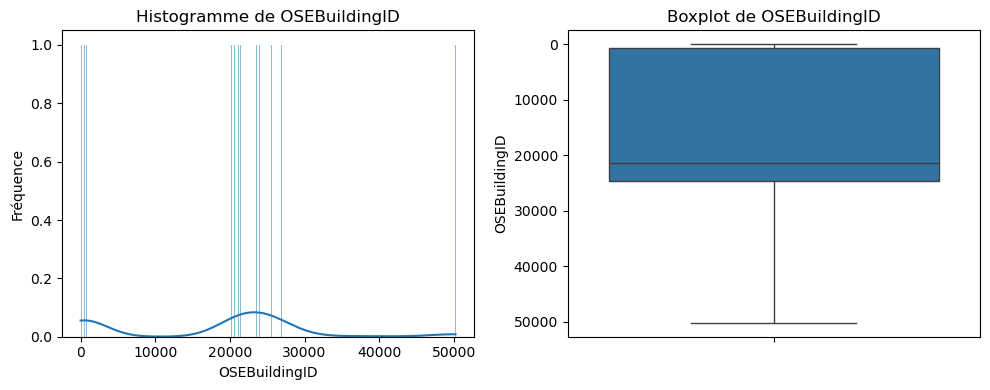

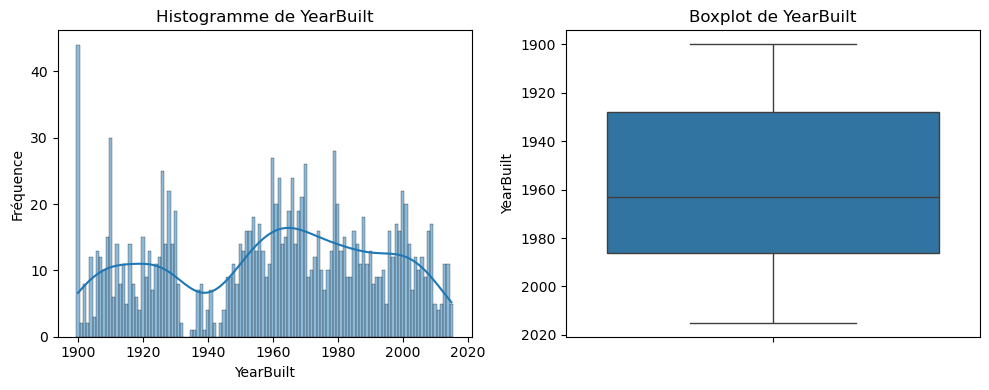

In [54]:
# Visualisation des variables catégorielles
histoBoxPlotQuanti(data_clean, quali)

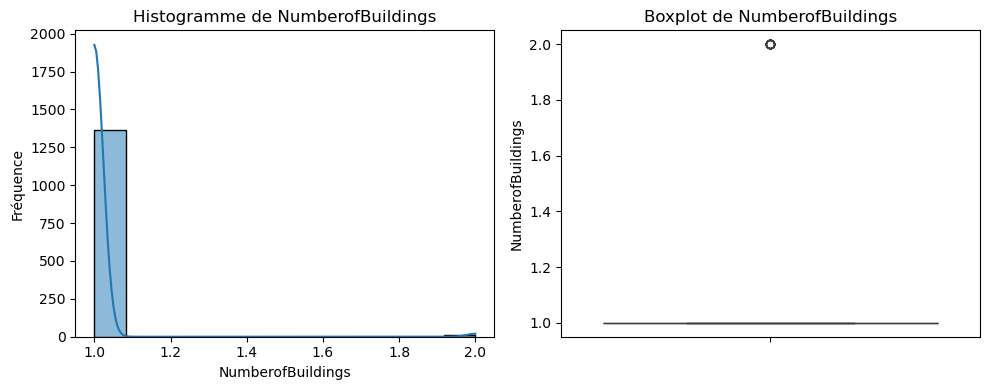

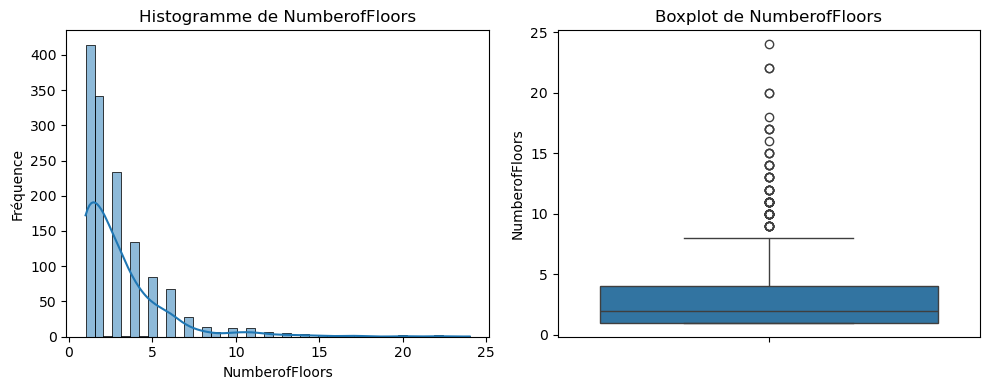

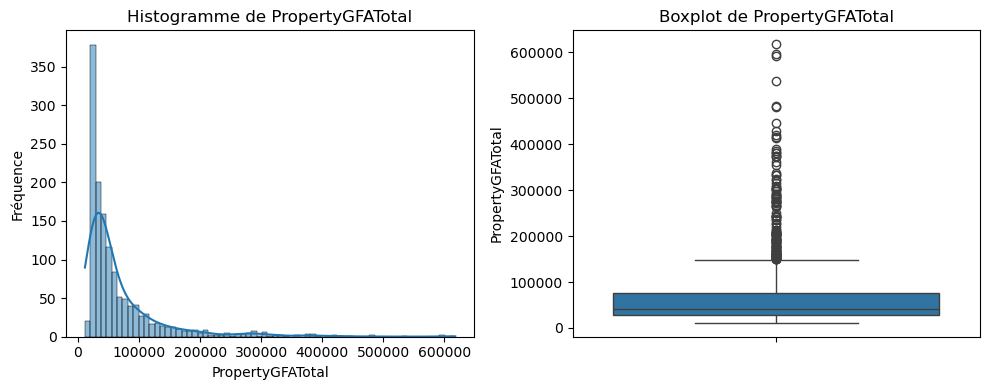

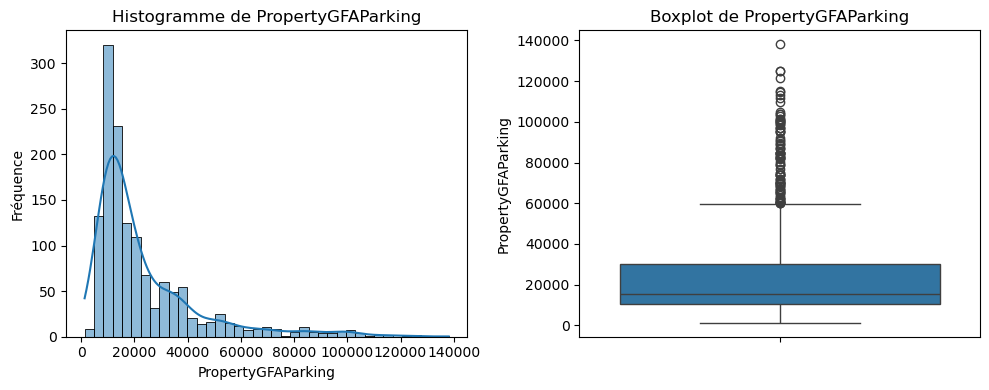

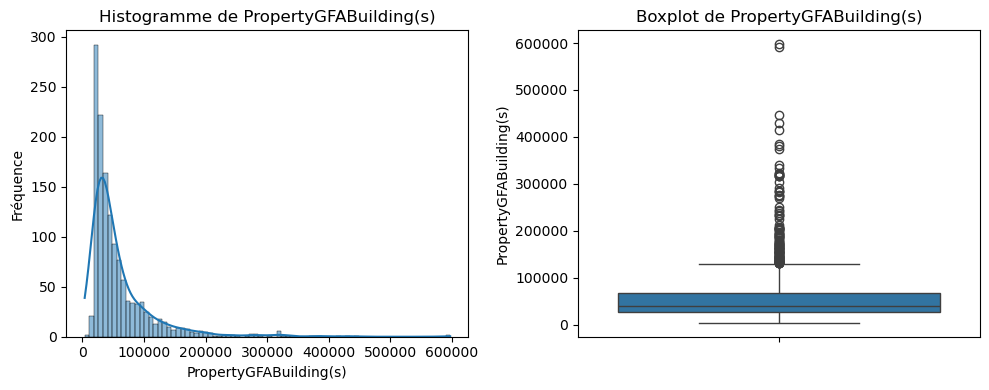

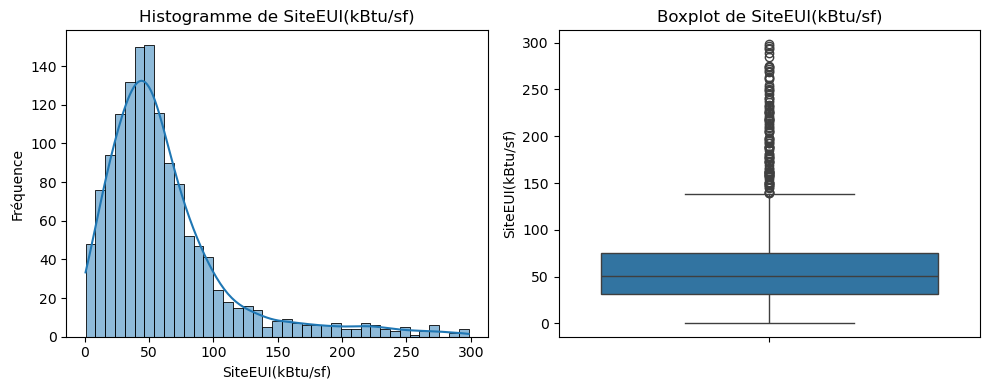

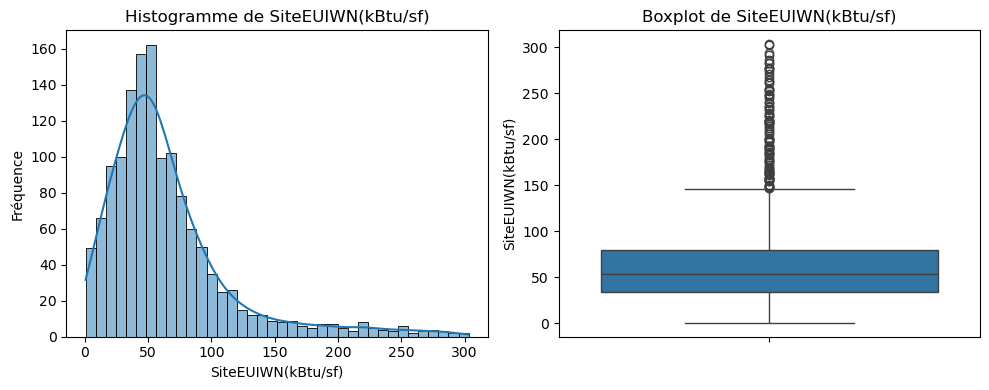

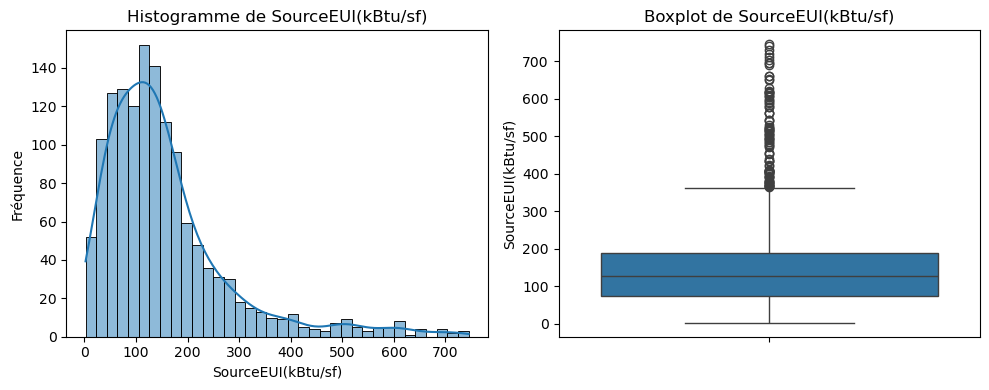

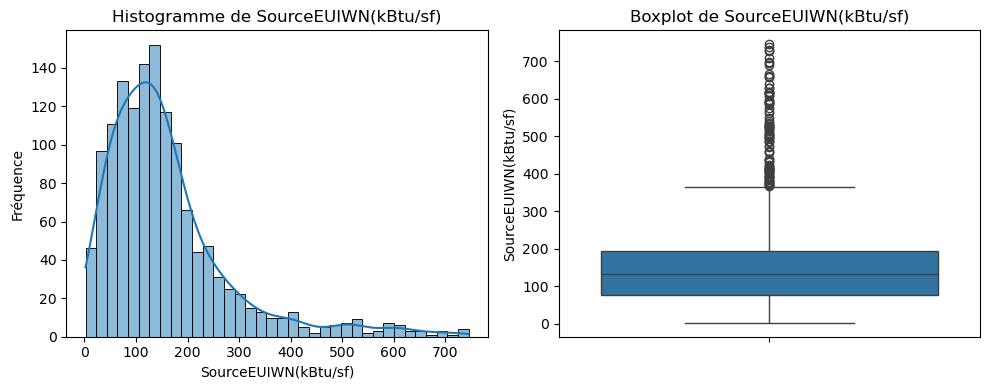

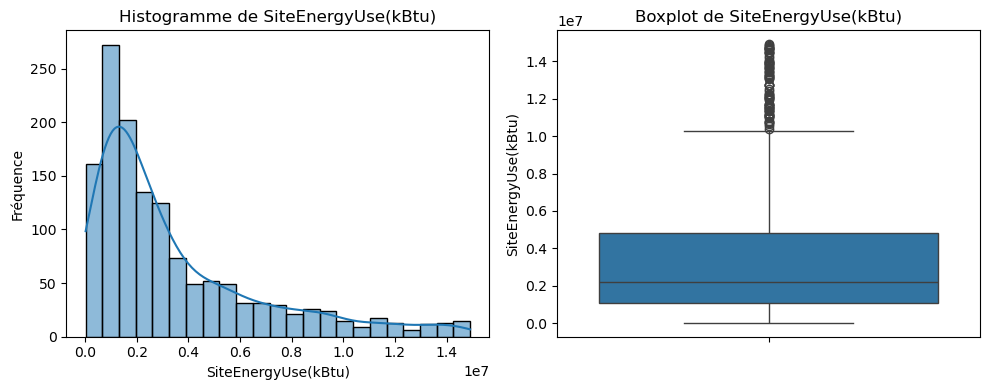

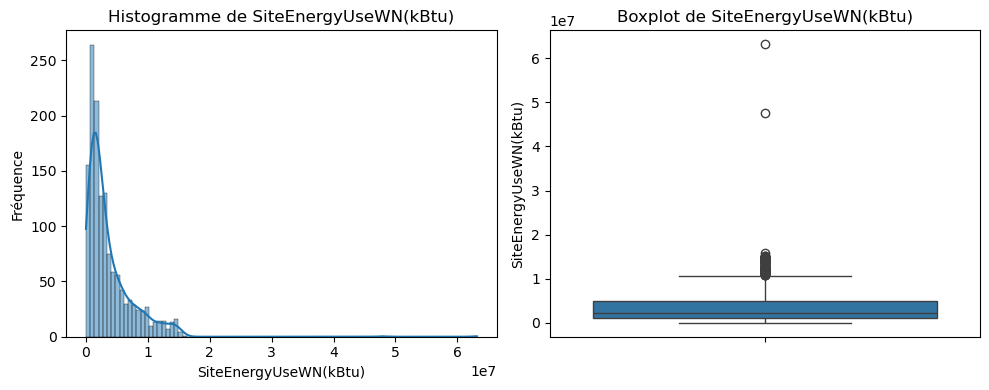

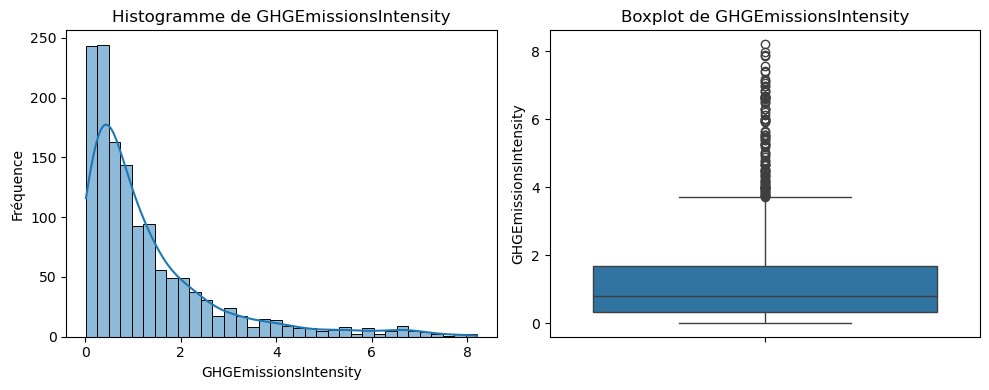

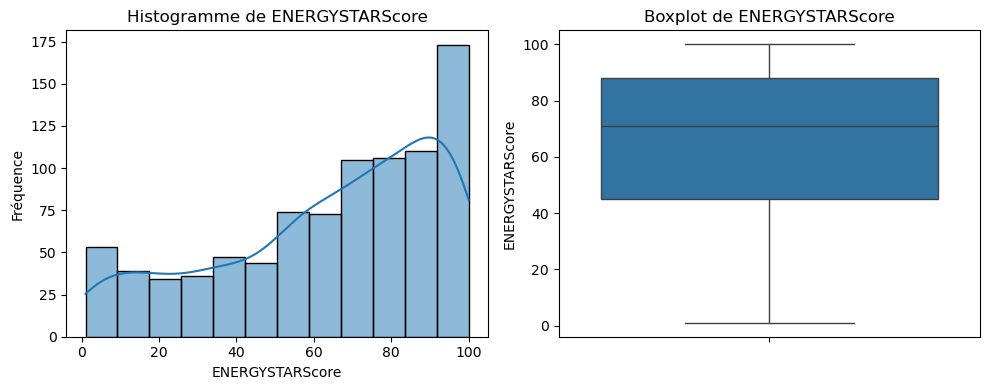

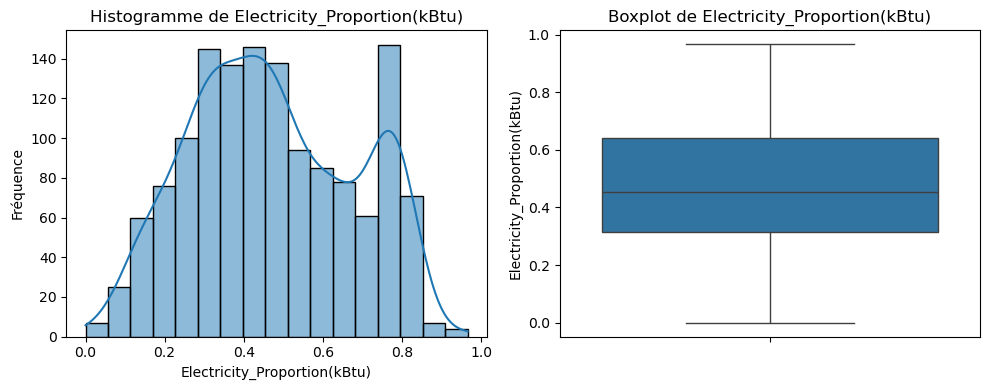

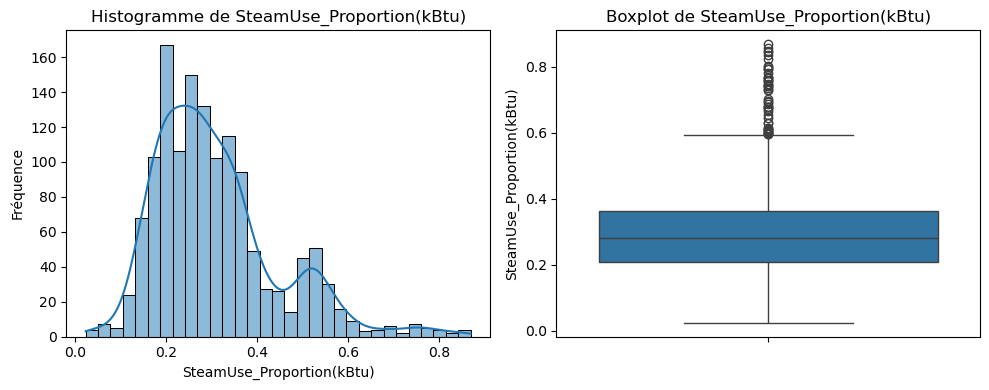

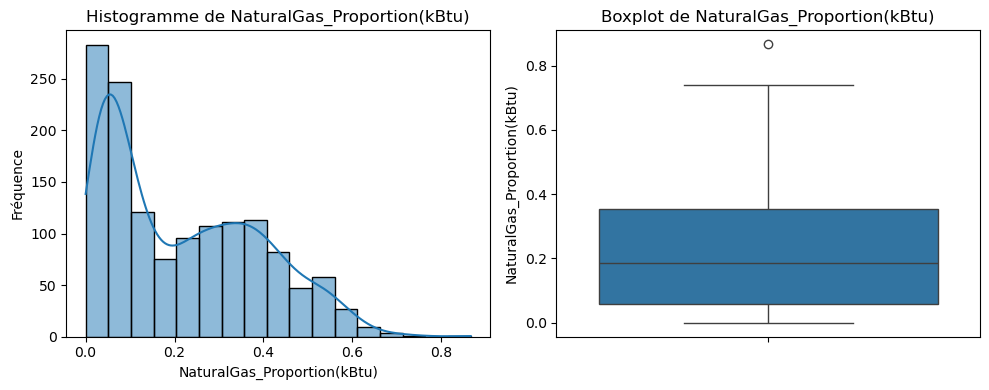

In [55]:
# Visualisation des variables continues
histoBoxPlotQuanti(data_clean, quanti)

<div style="background-color: RGB(93, 173, 226);" >
    <h5 style="margin: auto; padding: 20px; color:#fff; "> Bivariée </h5>
</div>

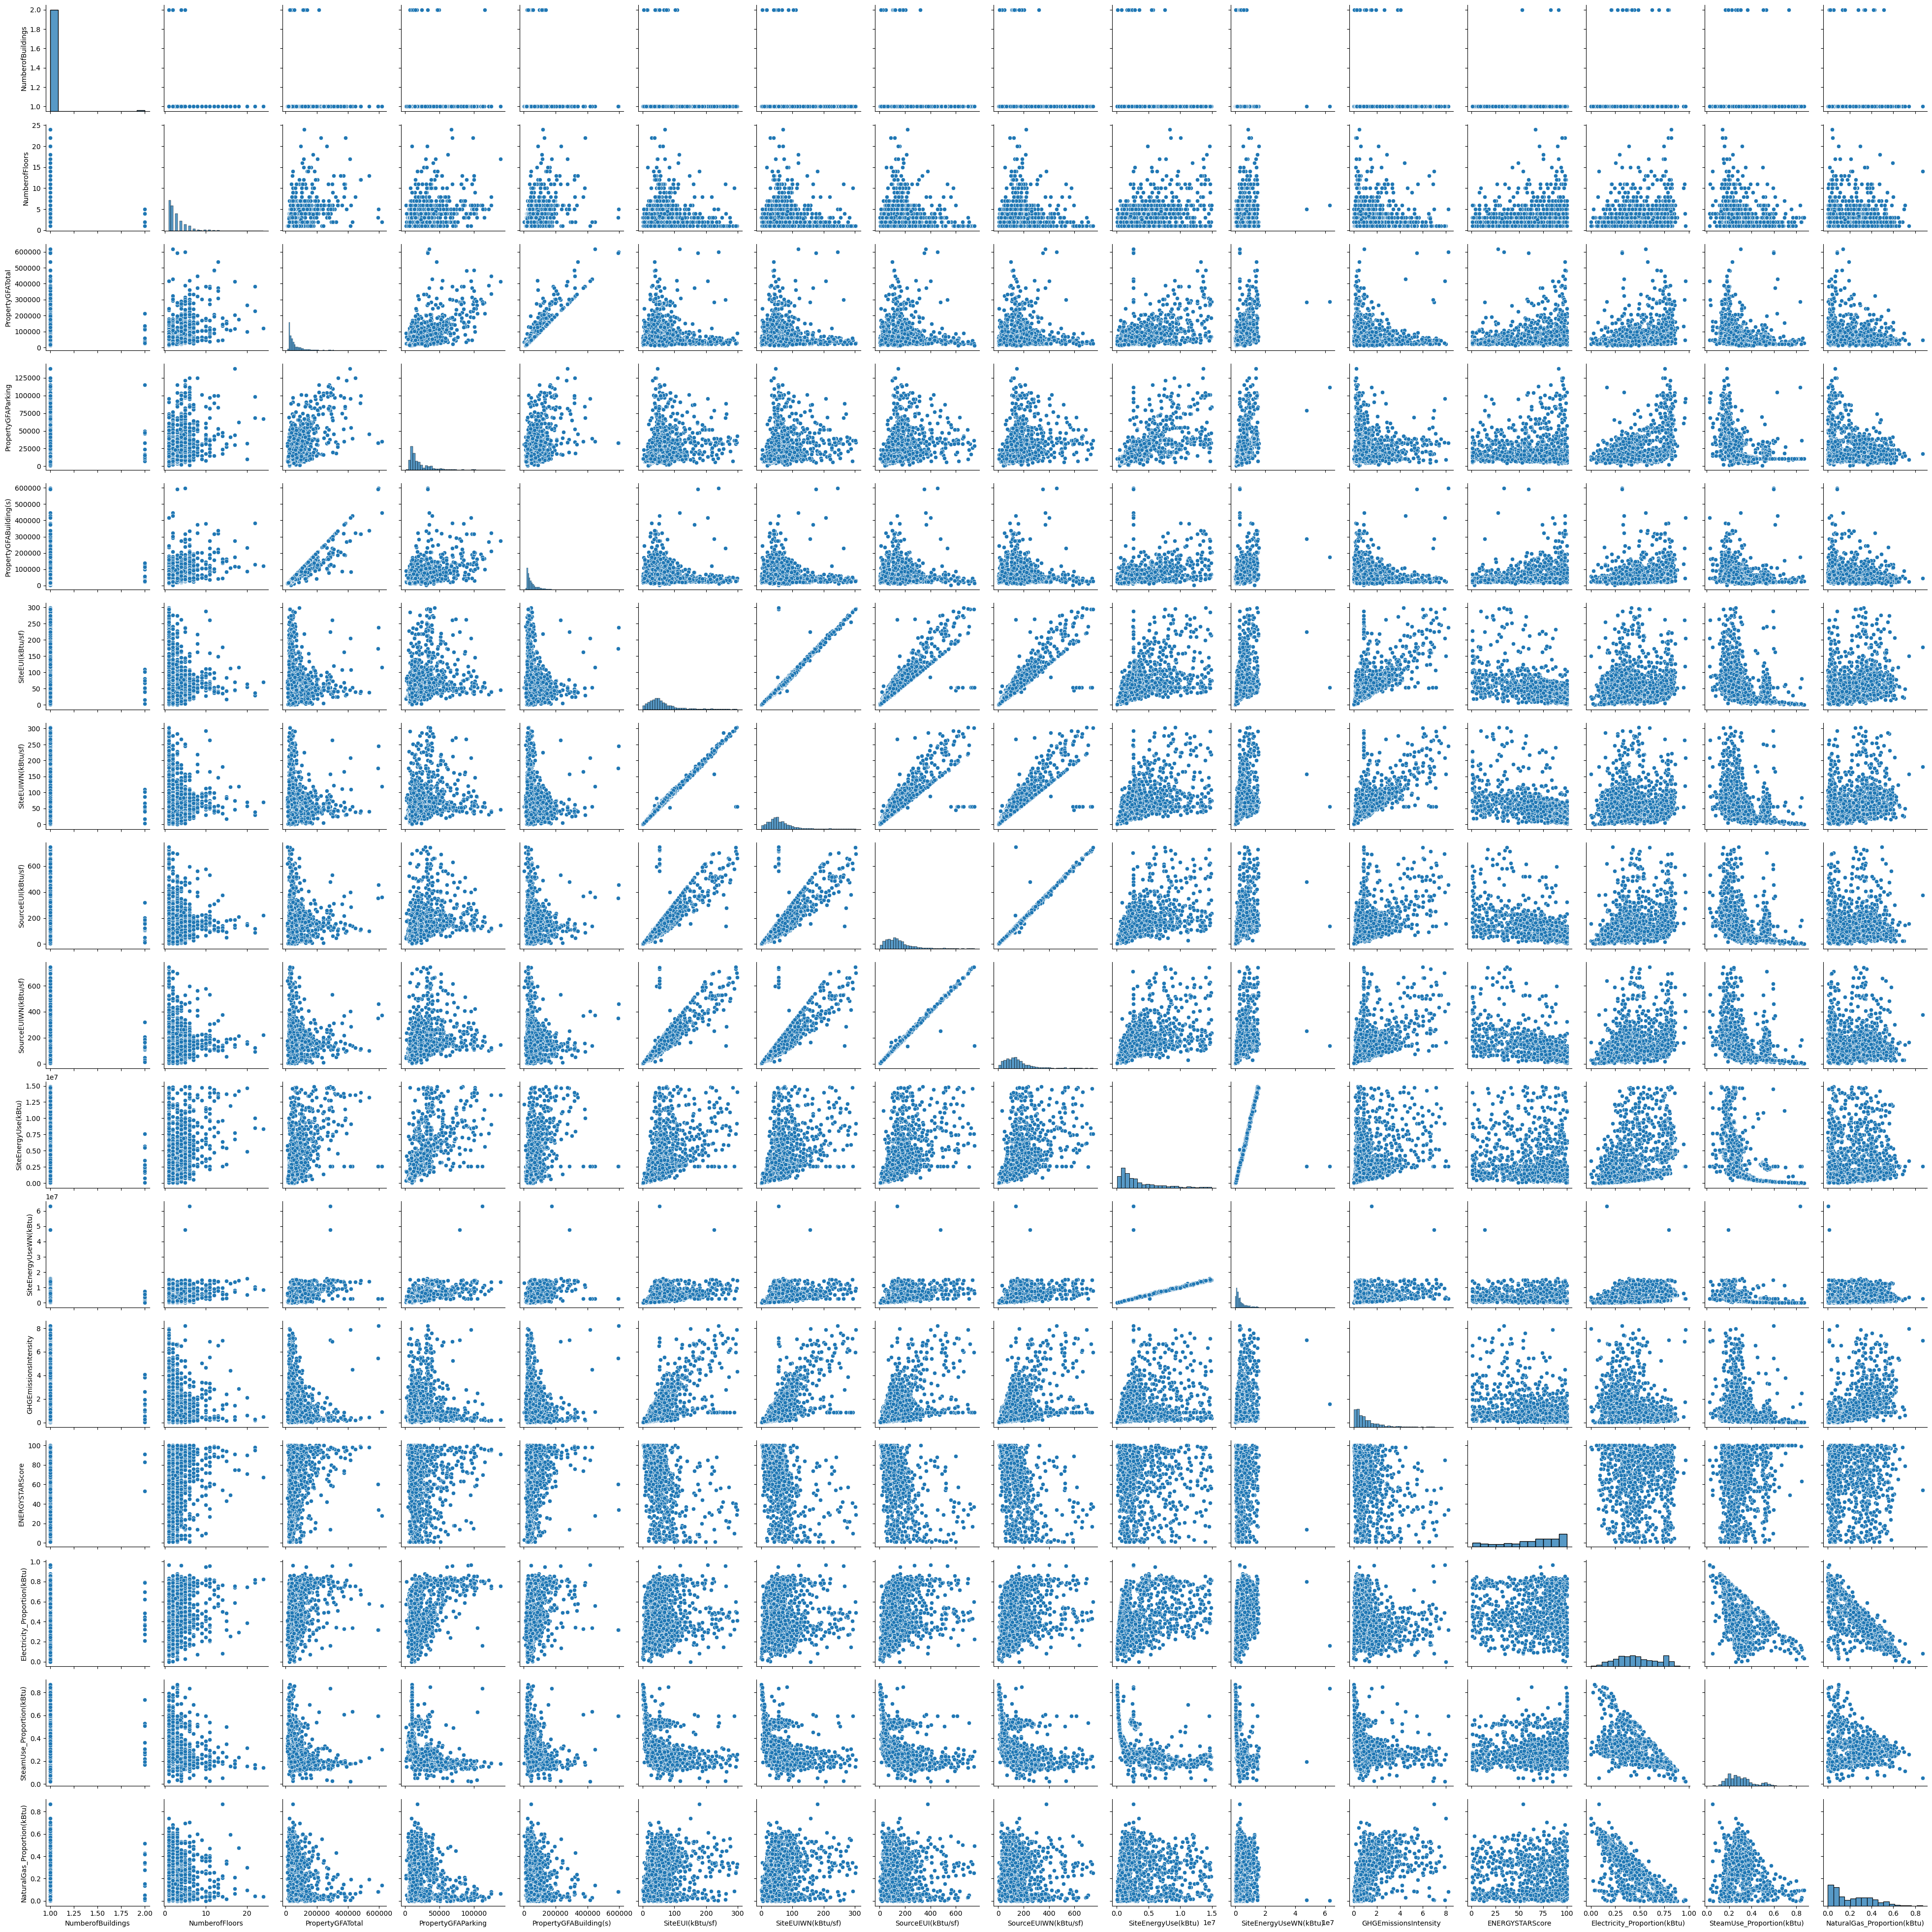

In [56]:
sns.pairplot(data_clean[quanti])

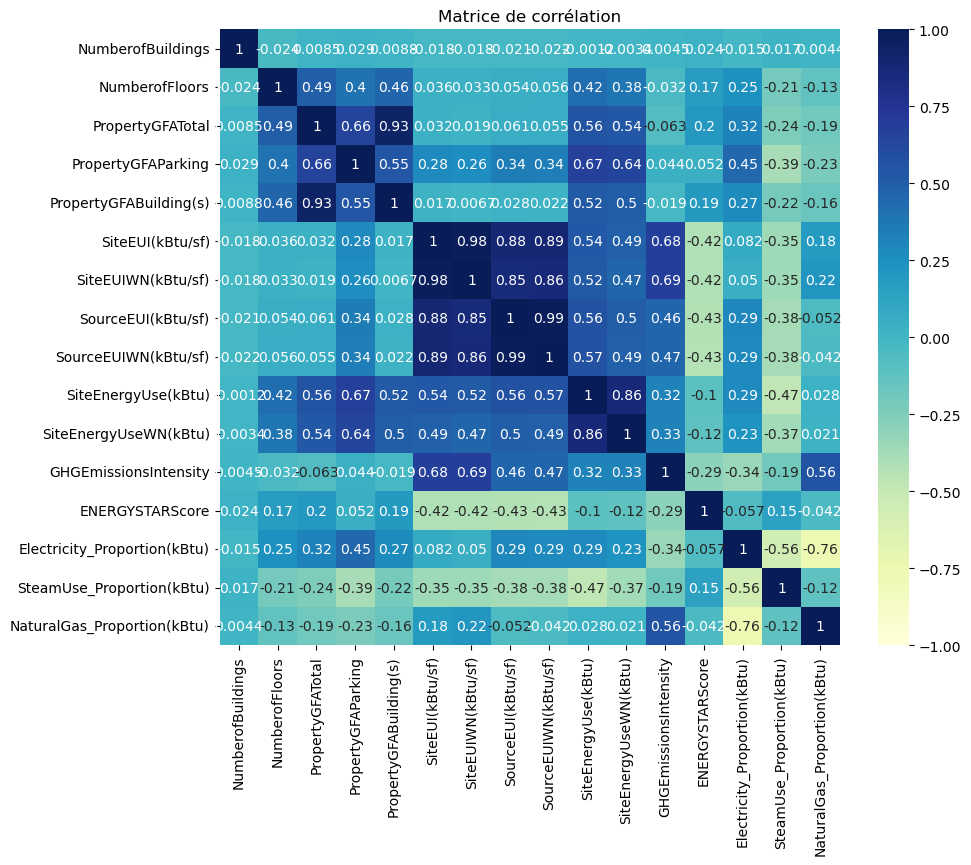

In [57]:
def heatmap(data, colonnes, check_normality=False):
    if check_normality:
        for col in colonnes:
            stat, p = st.shapiro(data[col])
            if p <= 0.05:
                print(f"La colonne {col} ne suit pas une distribution normale (p={p:.3f}).")
    
    # Calculer la matrice de corrélation
    corr_matrix = data[colonnes].corr()
    
    # Tracer la carte thermique
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='YlGnBu', vmin=-1, vmax=1)
    plt.title("Matrice de corrélation")
    plt.show()

heatmap(data_clean, quanti)

In [58]:
# Suppéssion des features trop corrélées (supérieur à 0.7)
features_corr = ['PropertyGFAParking', 'SiteEUIWN(kBtu/sf)', 'SourceEUIWN(kBtu/sf)', 'SiteEnergyUseWN(kBtu)', 'PropertyGFABuilding(s)', 'SourceEUI(kBtu/sf)', 'NaturalGas_Proportion(kBtu)']

data_clean = data_clean.drop(columns= features_corr)
data_clean.head()

,OSEBuildingID,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,SiteEUI(kBtu/sf),SiteEnergyUse(kBtu),GHGEmissionsIntensity,ENERGYSTARScore,Electricity_Proportion(kBtu),SteamUse_Proportion(kBtu)
0,1,1927,1.0,12.0,88434.0,81.699997,7226362.50,2.83,60.0,0.546060,0.277302
1,2,1996,1.0,11.0,103566.0,94.800003,8387933.00,2.86,61.0,0.297569,0.230310
2,3,1969,1.0,2.0,47237.0,96.000000,2615247.75,2.19,43.0,0.405656,0.223646
3,5,1926,1.0,10.0,61320.0,110.800003,6794584.00,4.67,56.0,0.407519,0.325913
4,8,1980,1.0,18.0,175580.0,114.800003,14172606.00,2.88,75.0,0.290734,0.232490


In [59]:
descriptionData(data_clean)

La dataframe contient 1381 lignes et 11 colonnes.


In [60]:
data_clean.isnull().sum()

OSEBuildingID                     0
YearBuilt                         0
NumberofBuildings                 0
NumberofFloors                    0
PropertyGFATotal                  0
SiteEUI(kBtu/sf)                  0
SiteEnergyUse(kBtu)               0
GHGEmissionsIntensity             0
ENERGYSTARScore                 487
Electricity_Proportion(kBtu)      0
SteamUse_Proportion(kBtu)         0
dtype: int64

In [61]:
data_clean.head()

,OSEBuildingID,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,SiteEUI(kBtu/sf),SiteEnergyUse(kBtu),GHGEmissionsIntensity,ENERGYSTARScore,Electricity_Proportion(kBtu),SteamUse_Proportion(kBtu)
0,1,1927,1.0,12.0,88434.0,81.699997,7226362.50,2.83,60.0,0.546060,0.277302
1,2,1996,1.0,11.0,103566.0,94.800003,8387933.00,2.86,61.0,0.297569,0.230310
2,3,1969,1.0,2.0,47237.0,96.000000,2615247.75,2.19,43.0,0.405656,0.223646
3,5,1926,1.0,10.0,61320.0,110.800003,6794584.00,4.67,56.0,0.407519,0.325913
4,8,1980,1.0,18.0,175580.0,114.800003,14172606.00,2.88,75.0,0.290734,0.232490


In [62]:
# exporter la dataframe finale
data_clean.to_csv("data_batiment_2016_clean.csv")